# 🧪 DFT Research Studio: Evaluating Topological vs. Dense Retrieval in Quantum Chemistry

### **Abstract**
This research project investigates the performance and robustness of **Graph-based Retrieval-Augmented Generation (GraphRAG)** compared to traditional **Dense Vector RAG** within the specialized domain of Density Functional Theory (DFT). By constructing a large-scale knowledge graph (19,000+ nodes) from scientific datasets and a corpus of high-impact PDFs, we evaluate how different retrieval architectures handle increasing levels of 'informational noise'—implemented via controlled distractor ratios (0% to 300%).

### **Key Research Objectives**
1. **Topological Precision**: Determine if graph-anchored retrieval reduces hallucinations in complex chemical queries.
2. **Noise Sensitivity**: Identify the 'breaking point' of vector-based retrieval when distractors dominate the search space.
3. **Multi-Agent Orchestration**: Evaluate the efficiency of a strategist/critic workflow for automated fallback between structured and unstructured data.
4. **Generative Fidelity**: Calculate the 'Fidelity Gap' (GFG) to measure the loss of accuracy across architectural shifts.

### **Methodology Highlights**
* **Retriever Suite**: BM25, Standard RAG (ChromaDB), GraphRAG (Star-Topology), and Multi-Agent Systems.
* **Evaluation**: LLM-as-a-Judge (Llama-3.1) scoring for Correctness, Relevance, and Groundedness.
* **Visualization**: Real-time SVG topological traces and stratified performance heatmaps.

## INSTALL AND IMPORT LIBRARIES

This initial cell establishes the computational environment by performing a vectorized installation of required dependencies. It leverages pip for automated package management, incorporating standard numerical libraries like pandas and numpy, alongside specialized frameworks for graph-based retrieval (networkx, pyvis), vector embeddings (chromadb, langchain), and large language model orchestration (groq). Additionally, the spacy transformer model en_core_web_sm is initialized to support downstream natural language processing and entity extraction tasks.

In [ ]:
%%capture
!pip install pandas networkx langchain langchain-community langchain-openai chromadb sentence-transformers scikit-learn numpy rouge-score groq spacy thefuzz pypdf pymupdf pyvis langchain-text-splitters gradio rank_bm25
!python -m spacy download en_core_web_sm

This cell serves as the project's global import interface, consolidating the necessary modules for data engineering, graph theory, and language modeling. It initializes the core data stack using Pandas and NumPy, establishes the GraphRAG foundation via NetworkX and Pyvis, and configures the retrieval pipeline through LangChain and ChromaDB. Furthermore, it integrates specialized NLP resources by loading SpaCy for entity extraction, NLTK for tokenization, and the Sentence-Transformer architecture for high-dimensional vector representations.

In [ ]:
import os
import glob
import pandas as pd
import networkx as nx
import numpy as np
import json
import time
import re
import io
import sys
import platform
import psutil
import torch
import hashlib
import random
import concurrent.futures
import threading
import fitz
import spacy
import chromadb
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import math
from google.colab import userdata
import importlib.metadata
from typing import List, Dict, Any, Tuple, Union
from tqdm import tqdm
from sklearn.metrics import ndcg_score
from collections import Counter
from rouge_score import rouge_scorer
from datetime import datetime
from IPython.display import HTML, SVG, Image, Markdown, display
from pyvis.network import Network
from rank_bm25 import BM25Okapi
from thefuzz import fuzz, process, utils
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from groq import Groq
import gradio as gr

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 1. CONFIGURATION & SETUP

This configuration class centralizes the experiment's global parameters to ensure reproducibility and modularity. It defines the structural foundation of the project by specifying absolute file paths for the knowledge graph components and PDF corpora. Furthermore, it establishes the retrieval logic by setting top-k constraints, random seeds for deterministic sampling, and the distribution ratios for distractor noise. Finally, it maps the question levels to specific indices and documents the licensing for both the datasets and the language models employed in the study.



In [ ]:
class Config:
    # File Paths
    NODES_PATH = "/content/drive/MyDrive/Dissertation/Datasets/Dataset/dft_kg_nodes.csv"
    RELS_PATH = "/content/drive/MyDrive/Dissertation/Datasets/Dataset/dft_kg_relationships.csv"
    QA_PATH = "/content/drive/MyDrive/Dissertation/Datasets/Dataset/_DFT-QA-120.csv"

    PAPER_DIR = "/content/drive/MyDrive/Dissertation/Datasets/DFT-Corpus-25"    # Folder with 25 relevant PDFs
    DISTRACTOR_DIR = "/content/drive/MyDrive/Dissertation/Datasets/distractors" # Folder with 75 distractor PDFs

    # ChromaDB Persistence Paths
    CHROMA_PERSIST_DIR_CLEAN = "/content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_clean"
    CHROMA_PERSIST_DIR_NOISY = "/content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_noisy"
    CHROMA_PERSIST_DIR_BASE = "/content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_ratio"

    # Experiment Settings
    MODELS_TO_TEST = [ "llama-3.1-8b-instant"]


    TOP_K_RETRIEVAL = 5
    RANDOM_SEED = 42
    SPACY_MODEL = "en_core_web_sm"

    # New Experiment Parameters
    DISTRACTOR_RATIOS = [0.0, 0.5, 1.0, 2.0, 3.0] # 0%, 50%, 100%, 200%, 300% distractors relative to relevant papers
    QUESTION_LEVELS = {
        'L1': (0, 30),  # Questions Q1.1v0 to Q1.10v2 (3 variations each for 10 original questions)
        'L2': (30, 60), # Questions Q2.1v0 to Q2.10v2
        'L3': (60, 90), # Questions Q3.1v0 to Q3.10v2
        'L4': (90, 120) # Questions Q4.1v0 to Q4.10v2
    }

    # Licensing Information (NEW)
    DATA_LICENSE = "CC BY-NC 4.0"
    MODEL_LICENSES = {
        "llama-3.1-8b-instant": "Llama 3.1 Community License (Meta)",
        "sentence-transformers/all-MiniLM-L6-v2": "Apache-2.0"
    }

This class implements a specialized processing pipeline for scientific PDF ingestion. It utilizes a modular approach to text sanitization, employing regex-based methods to resolve hyphenation artifacts, normalize Unicode ligatures, and eliminate in-text citation noise. The extraction logic leverages PyMuPDF to parse document structure, applying spatial filtering to exclude margin-based artifacts like headers and footers. Finally, it employs a heuristic sectioning algorithm to partition raw strings into semantically coherent scientific blocks—such as Abstract, Methods, and Results—facilitating granular downstream retrieval.

In [ ]:
class ScientificPDFProcessor:
    @staticmethod
    def clean_text(text):
        """Basic text cleaning for PDF extracts."""
        # Fix hyphenation at the end of lines
        text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)
        # Replace common ligatures
        text = text.replace('ﬁ', 'fi').replace('ﬂ', 'fl')
        # Remove excessive newlines
        text = re.sub(r'\n{2,}', '\n\n', text)
        # Remove excessive whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    @staticmethod
    def clean_citations(text):
        """Remove in-text citations, e.g., [1], [1-3], [1, 2, 5]."""
        text = re.sub(r'\[[\d, -]+\]', '', text)
        text = re.sub(r'\([\d\w, -]+\)', '', text)
        return text

    @staticmethod
    def extract_sections(pdf_path) -> Dict[str, str]:
        """Extracts and sections text from a PDF using PyMuPDF."""
        full_raw_text = ""
        try:
            doc = fitz.open(pdf_path)
            for page_num in range(len(doc)):
                page = doc.load_page(page_num)

                # Skip headers (top 8%) and footers (bottom 8%)
                margin_top = 0.08
                margin_bottom = 0.92

                page_rect = page.rect
                content_rect = fitz.Rect(
                    page_rect.x0,
                    page_rect.y0 + page_rect.height * margin_top,
                    page_rect.x1,
                    page_rect.y1 - (page_rect.height * (1 - margin_bottom))
                )

                full_raw_text += page.get_text("text", clip=content_rect)
                full_raw_text += "\n"
            doc.close()
        except Exception as e:
            print(f" Error reading {os.path.basename(pdf_path)}: {e}")
            return {}

        # Regex to identify scientific headers
        section_pattern = r'(^\s*(?:[IVXLCDM]+\.|\d+\.|[A-Z]\.)?\s*(?:ABSTRACT|INTRODUCTION|METHODS|RESULTS|DISCUSSION|CONCLUSION|REFERENCES|ACKNOWLEDG(?:E)?MENTS|SUPPORTING INFORMATION|COMPUTATIONAL DETAILS)(?:\s[A-Z]+)*\s*$)'

        parts = re.split(section_pattern, full_raw_text, flags=re.IGNORECASE | re.MULTILINE)

        sections = {}
        if len(parts) > 1:
            # Header/Title Info
            sections["HEADER"] = ScientificPDFProcessor.clean_text(parts[0])

            # Iterate pairs: (Header Name, Content)
            for i in range(1, len(parts), 2):
                if i + 1 < len(parts):
                    header_name = ScientificPDFProcessor.clean_text(parts[i]).upper()
                    section_text = ScientificPDFProcessor.clean_text(parts[i+1])
                    section_text = ScientificPDFProcessor.clean_citations(section_text)
                    sections[header_name] = section_text
        else:
            # Fallback: Treat whole doc as one section
            sections["CONTENT"] = ScientificPDFProcessor.clean_text(full_raw_text)

        return sections

## 2. DATA LOADER & KNOWLEDGE GRAPH BUILDER

This class serves as the central data orchestration layer, managing the ingestion of relational graph data and the scientific corpus. It automates the construction of a directed NetworkX graph by mapping CSV-defined nodes and edges to a functional in-memory structure. Additionally, it implements a randomized distractor injection logic for controlled noise experiments and incorporates a robust parsing routine for QA pairs, ensuring precise extraction of ground-truth document identifiers through optimized regular expression matching.

In [ ]:
class DFTDataManager:
    def __init__(self, config):
        self.config = config
        self.nodes_df = pd.read_csv(config.NODES_PATH)
        self.rels_df = pd.read_csv(config.RELS_PATH)
        self.qa_df = pd.read_csv(config.QA_PATH)
        # Clean column names to strip whitespace
        self.qa_df.columns = self.qa_df.columns.str.strip()
        self.graph = self._build_graph()

    def _build_graph(self):
        """Constructs a NetworkX graph from the specific CSV structure."""
        G = nx.DiGraph()

        # Add Nodes
        for _, row in self.nodes_df.iterrows():
            attrs = row.dropna().to_dict()
            if 'node_id' in attrs:
                G.add_node(row['node_id'], **attrs)

        # Add Edges
        for _, row in self.rels_df.iterrows():
            if pd.notna(row['source_id']) and pd.notna(row['target_id']):
                G.add_edge(
                    row['source_id'],
                    row['target_id'],
                    relationship=row['relationship_type'],
                    paper_id=row.get('paper_id', 'Unknown')
                )
        return G

    def load_pdfs(self, distractor_ratio: float = 0.0) -> List[Document]:
            docs = []
            relevant_files = glob.glob(os.path.join(self.config.PAPER_DIR, "*.pdf"))
            distractor_files = glob.glob(os.path.join(self.config.DISTRACTOR_DIR, "*.pdf"))

            num_relevant_files = len(relevant_files)
            num_distractors_to_include = int(num_relevant_files * distractor_ratio) if distractor_ratio > 0 else 0

            selected_distractor_files = []
            if num_distractors_to_include > 0 and len(distractor_files) > 0:
                random.seed(self.config.RANDOM_SEED)
                num_to_sample = min(num_distractors_to_include, len(distractor_files))
                selected_distractor_files = random.sample(distractor_files, num_to_sample)

            files_to_process = relevant_files + selected_distractor_files
            print(f" Processing {len(files_to_process)} PDFs ({num_relevant_files} relevant, {len(selected_distractor_files)} distractors) with Scientific Sectioning...")

            for f in files_to_process:
                sections = ScientificPDFProcessor.extract_sections(f)
                for section_name, text in sections.items():
                    if len(text) < 50: continue
                    doc = Document(
                        page_content=text,
                        metadata={
                            "source": os.path.basename(f),
                            "section": section_name
                        }
                    )
                    docs.append(doc)
            return docs

    def get_qa_pairs(self):
        """Returns list of dicts with properly parsed gold_docs list."""
        pairs = []
        for _, row in self.qa_df.iterrows():
            gold_docs_str = str(row.get("Gold Standard Document", "")).strip()
            question_number = str(row.get("Question number", "")).strip()

            match_original = re.match(r"(Q\d+\.\d+)", question_number)
            original_question_identifier = match_original.group(1) if match_original else question_number
            match_variation = re.search(r"(v\d+)", question_number)
            variation_type = match_variation.group(1) if match_variation else "original"

            # NEW: Robustly split comma-separated PDF names
            gold_docs_list = []
            if gold_docs_str:
                # Split by '.pdf' to handle filenames that contain internal commas
                raw_parts = [p.strip() + ".pdf" for p in gold_docs_str.split(".pdf") if p.strip()]
                for part in raw_parts:
                    # Clean up leading commas/spaces from split
                    clean_name = re.sub(r"^[\s,]+", "", part)
                    if clean_name.lower().endswith(".pdf"):
                        gold_docs_list.append(clean_name)

            pairs.append({
                "id": question_number,
                "original_question_identifier": original_question_identifier,
                "variation_type": variation_type,
                "question": row["Question"],
                "ground_truth": row["Ground truth"],
                "gold_docs": gold_docs_list
            })
        return pairs

### A. Verify Data Loading

This routine provides a diagnostic validation of the data ingestion pipeline. It instantiates the configuration and data management layers to verify the integrity of the relational schema, specifically inspecting the head of the node, relationship, and question-answering DataFrames. Furthermore, it performs a structural audit of the QA interface to resolve specific metadata columns and executes a sample retrieval to validate the regex-based extraction of gold-standard document identifiers.

In [ ]:
# Instantiate Config and DFTDataManager
config = Config()
dm = DFTDataManager(config)

print("--- Verifying Data Loading ---")
print("\nNodes DataFrame Head:")
display(dm.nodes_df.head())

print("\nRelationships DataFrame Head:")
display(dm.rels_df.head())

print("\nQA Pairs DataFrame Head:")
display(dm.qa_df.head())

# Print all columns to identify the correct gold docs column
print("\nActual Columns in QA DataFrame:")
print(dm.qa_df.columns)

# Get all QA pairs and display gold_docs for the first one
qa_pairs_list = dm.get_qa_pairs()
print(f"\nTotal QA pairs loaded: {len(qa_pairs_list)}")
if qa_pairs_list:
    print(f"Gold docs for first QA pair ({qa_pairs_list[0]['id']}): {qa_pairs_list[0]['gold_docs']}")
else:
    print("No QA pairs loaded.")

--- Verifying Data Loading ---

Nodes DataFrame Head:


,node_id,label,rung,class,family,unit,value,source
0,A generally applicable atomic-charge dependent...,Paper,NaN,NaN,NaN,NaN,NaN,NaN
1,D4,DispersionCorrection,NaN,NaN,NaN,NaN,NaN,NaN
2,D3,DispersionCorrection,NaN,NaN,NaN,NaN,NaN,NaN
3,D3(BJ),DispersionCorrection,NaN,NaN,NaN,NaN,NaN,NaN
4,D3(BJ)-ATM,DispersionCorrection,NaN,NaN,NaN,NaN,NaN,NaN



Relationships DataFrame Head:


,paper_id,source_id,target_id,relationship_type,condition
0,Caldeweyher2019,Caldeweyher2019,D4,DEVELOPS,NaN
1,Caldeweyher2019,D4,D3,REFINES_DISPERSION_CORRECTION,NaN
2,Caldeweyher2019,D4-ATM,D3(BJ)-ATM,REFINES_DISPERSION_CORRECTION,NaN
3,Caldeweyher2019,D4-MBD,D3(BJ)-ATM,REFINES_DISPERSION_CORRECTION,NaN
4,Caldeweyher2019,Caldeweyher2019,D3,CITES,NaN



QA Pairs DataFrame Head:


,Question number,Question,Ground truth,Gold Standard Document
0,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,A new local density functional for main-group ...
1,Q1.1v1,What specific physical dependencies and chemic...,The M06-L functional is a new local density fu...,A new local density functional for main-group ...
2,Q1.1v2,For which types of bonding and thermochemistry...,The M06-L functional is a new local density fu...,A new local density functional for main-group ...
3,Q1.2v0,How many different test sets does the GMTKN55 ...,The GMTKN55 database covers 55 different test ...,A look at the density functional theory zoo wi...
4,Q1.2v1,What is the total count of subsets and resulti...,The GMTKN55 database covers 55 different test ...,A look at the density functional theory zoo wi...



Actual Columns in QA DataFrame:
Index(['Question number', 'Question', 'Ground truth',
       'Gold Standard Document'],
      dtype='object')

Total QA pairs loaded: 120
Gold docs for first QA pair (Q1.1v0): ['A new local density functional for main-group thermochemistry transition.pdf', 'The M06 suite of density functionals for main group thermochemistry.pdf']


### B. Verify PDF Loading

This diagnostic block serves as a verification test for the PDF ingestion module's connectivity and access permissions. It attempts to load a subset of the scientific corpus—excluding distractor noise—to confirm that the local file system paths are correctly resolved. Upon successful execution, it reports the total number of document chunks indexed and performs a metadata inspection on the primary source to ensure the integrity of the document-to-source mapping.



In [ ]:
# Test PDF loading (loading a few just to confirm directory access)
print("\nLoading a few sample PDFs to verify access...")
try:
    # Load without distractors (ratio 0.0) for a quicker check
    sample_docs = dm.load_pdfs(distractor_ratio=0.0)
    print(f"Successfully loaded {len(sample_docs)} PDF chunks (from relevant papers).")
    if sample_docs:
        print("First document source:", sample_docs[0].metadata.get('source'))
except Exception as e:
    print(f"Error loading PDFs: {e}")

print("--- Data Verification Complete ---")


Loading a few sample PDFs to verify access...
 Processing 25 PDFs (25 relevant, 0 distractors) with Scientific Sectioning...
Successfully loaded 121 PDF chunks (from relevant papers).
First document source: Density-fnnctional exchange-energy approximation with correct asymptotic behavior.pdf
--- Data Verification Complete ---


## 3. RETRIEVAL ENGINES (MODULAR)

### BM25 Retriever

This class implements a lexical retrieval engine based on the BM25 (Best Matching 25) probabilistic ranking function. Upon initialization, it tokenizes the corpus via NLTK, transforming raw document content into a normalized term frequency representation. The retrieval logic calculates relevance scores for a given query against the indexed document chunks, returning the top-k candidates prioritized by their statistical significance within the corpus.

In [ ]:
class BM25Retriever:
    def __init__(self, documents: List[Document]):
        self.documents = documents
        tokenized_documents = []
        for doc in documents:
            # Ensure content is a string before tokenizing
            if isinstance(doc.page_content, str):
                tokenized_documents.append(nltk.word_tokenize(doc.page_content.lower()))
            else:
                # Handle cases where page_content might not be a string (e.g., None, int, etc.)
                tokenized_documents.append([]) # Append empty list if content is not a string
                print(f"Warning: Document page_content is not a string for doc with metadata: {doc.metadata}")

        self.bm25 = BM25Okapi(tokenized_documents)
        print(f"BM25Retriever initialized with {len(documents)} documents.")

    def invoke(self, query: str, k: int = Config.TOP_K_RETRIEVAL) -> List[Document]:
        tokenized_query = nltk.word_tokenize(query.lower())
        scores = self.bm25.get_scores(tokenized_query)

        # Get the indices of the top k scores
        top_indices = np.argsort(scores)[::-1][:k]

        # Retrieve the original Document objects
        retrieved_docs = [self.documents[i] for i in top_indices]
        return retrieved_docs

print("BM25Retriever class defined.")

BM25Retriever class defined.


### Reranker

This class implements a neural reranking stage using a Cross-Encoder architecture to refine initial retrieval results. It leverages the 'ms-marco-MiniLM-L-6-v2' model to perform deep semantic comparison by scoring query-document pairs simultaneously. Unlike bi-encoders, this approach captures complex inter-dependencies between the query and context, allowing the engine to re-sort candidate documents in descending order of predicted relevance to ensure high-precision final output.

In [ ]:
class Reranker:
    def __init__(self):
        # Initialize a cross-encoder model for reranking
        # Using a pre-trained model suitable for cross-encoding (query-document scoring)
        self.model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
        print("Reranker initialized with 'cross-encoder/ms-marco-MiniLM-L-6-v2' model.")

    def invoke(self, query: str, documents: List[Document]) -> List[Document]:
        if not documents: # Handle empty documents list
            return []

        # Extract page_content from each Document object
        passages = [doc.page_content for doc in documents]

        # Pair the query with each passage
        sentence_pairs = [[query, passage] for passage in passages]

        # Use the cross-encoder model to predict scores
        # The .predict method returns scores directly
        scores = self.model.predict(sentence_pairs)

        # Create a list of (score, document) tuples
        scored_documents = list(zip(scores, documents))

        # Sort the documents based on scores in descending order
        scored_documents.sort(key=lambda x: x[0], reverse=True)

        # Return the re-ranked list of Document objects
        reranked_docs = [doc for score, doc in scored_documents]
        print(f"Reranked {len(reranked_docs)} documents for query: '{query[:50]}...'")
        return reranked_docs

print("Reranker class defined.")

Reranker class defined.


### BM25 Reranker Adapter

This class implements a hybrid retrieval strategy by orchestrating a two-stage pipeline. It first utilizes the BM25Retriever to perform a broad lexical search, capturing an expanded candidate set (defined as 2x the target k-value). Subsequently, it passes these candidates to a neural Reranker to resolve semantic relevance. This modular design ensures that the system maintains high recall through probabilistic ranking while achieving high precision via deep cross-encoded scoring, ultimately returning a refined subset of top-k documents.

In [ ]:
class BM25RerankerAdapter:
    def __init__(self, documents: List[Document], reranker: Reranker, top_k_retrieval: int = Config.TOP_K_RETRIEVAL):
        """
        Initializes the BM25RerankerAdapter.
        It uses BM25Retriever for initial retrieval and a Reranker for refining results.
        """
        self.bm25_retriever = BM25Retriever(documents)
        self.reranker = reranker
        self.top_k_retrieval = top_k_retrieval
        print(f"BM25RerankerAdapter initialized for {len(documents)} documents.")

    def invoke(self, query: str) -> List[Document]:
        """
        Performs initial BM25 retrieval, then reranks the results, and returns the top_k.
        This method is compatible with the `vector_retriever.invoke` signature.
        """
        # Retrieve more documents with BM25 to give the reranker more candidates
        # Typically, you'd retrieve K*N documents for the reranker, then take top K.
        # Let's retrieve 2*TOP_K for reranking.
        initial_retrieval_k = self.top_k_retrieval * 2
        bm25_docs = self.bm25_retriever.invoke(query, k=initial_retrieval_k)

        if not bm25_docs:
            return []

        # Rerank the retrieved documents
        reranked_docs = self.reranker.invoke(query, bm25_docs)

        # Return the top K documents after reranking
        final_docs = reranked_docs[:self.top_k_retrieval]

        return final_docs

print("BM25RerankerAdapter class defined.")

BM25RerankerAdapter class defined.


### Standard RAG

This class implements a baseline RAG pipeline using a dense vector retrieval architecture. It utilizes ChromaDB as the underlying vector store and leverages the 'all-MiniLM-L6-v2' transformer model to generate high-dimensional document embeddings. The constructor features an automated persistence check: it either restores a pre-indexed collection from disk or performs a cold start by partitioning raw documents into 1000-character segments via recursive character splitting. Finally, the class exposes a LangChain-compatible retriever interface, optimized to return the most semantically relevant contexts based on cosine similarity.



In [ ]:
class StandardRAG:
    def __init__(self, documents: List[Document], persist_directory: str):
        """Builds the Vector Store, persisting it if necessary."""
        self.persist_directory = persist_directory

        # Using HuggingFace Embeddings
        self.embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

        # Check if ChromaDB already exists at the persist_directory
        if os.path.exists(self.persist_directory) and os.listdir(self.persist_directory):
            print(f"Loading ChromaDB from {self.persist_directory}...")
            self.vector_store = Chroma(
                persist_directory=self.persist_directory,
                embedding_function=self.embeddings,
                collection_name="dft_experiment"
            )
        else:
            print(f"Creating and persisting new ChromaDB to {self.persist_directory}...")
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
            splits = text_splitter.split_documents(documents)

            print(f"Indexing {len(splits)} chunks into VectorStore...")
            self.vector_store = Chroma.from_documents(
                documents=splits,
                embedding=self.embeddings,
                collection_name="dft_experiment",
                persist_directory=self.persist_directory
            )
            self.vector_store.persist()

        # --- Diagnostic: Verify vector store content ---
        try:
            count = self.vector_store._collection.count()
            print(f"  Vector store initialized with {count} documents.")
            if count == 0 and len(documents) > 0:
                print("  WARNING: Vector store is empty despite input documents. Check document splitting/indexing.")

            # Small test retrieval
            if count > 0:
                test_query = "What is PBE0 functional?"
                test_retrieval = self.vector_store.similarity_search(test_query, k=1)
                if test_retrieval:
                    print(f"  Test retrieval successful. First doc content (snippet): {test_retrieval[0].page_content[:100]}...")
                else:
                    print("  Test retrieval returned no documents.")

        except Exception as e:
            print(f"  Error verifying vector store content: {e}")

        self.retriever = self.vector_store.as_retriever(search_kwargs={"k": Config.TOP_K_RETRIEVAL})

### GraphRAG

This code defines the GraphRAG engine, which implements a structured retrieval logic by traversing the relational knowledge graph. Here's a breakdown of how it works:

Initialization: It sets up fast lookups for nodes and attempts to load the SpaCy transformer model (en_core_web_sm) for natural language processing.
Fuzzy Entity Resolution: The find_closest_nodes method uses the thefuzz library to map user search terms to actual graph node IDs, even if there are slight misspellings or variations, using a 60% similarity threshold.

Star Context Algorithm: This is the 'magic function' (get_star_context).

 It:
Extracts scientific entities (Proper Nouns and Nouns) from the query.
Performs a 'Dragnet' search to find matching nodes in the CSV-based graph.
Executes Intersection Logic to find 'ValidationResult' nodes that act as hubs connecting the identified entities.
Packs these candidates into a formatted text buffer, including their types, numerical values, units, and connectivity.

Paranoid Prompting: The generate_paranoid_prompt method creates a strict instruction set for the LLM. It forces the model to act as a 'Precision Verifier,' instructing it to only use the provided graph evidence and to explicitly reject candidates that don't support every part of the user's query.



In [ ]:
class GraphRAG:
    def __init__(self, nodes_df, rels_df):
        self.nodes_df = nodes_df
        self.rels_df = rels_df

        print("Initializing GraphRAG NLP & Lookups...")
        # Create fast lookups (The logic you provided)
        self.node_map = self.nodes_df.set_index('node_id').to_dict('index')

        # Load SpaCy
        try:
            self.nlp = spacy.load(Config.SPACY_MODEL)
        except OSError:
            print(f"Spacy model '{Config.SPACY_MODEL}' not found. Downloading...")
            from spacy.cli import download
            download(Config.SPACY_MODEL)
            self.nlp = spacy.load(Config.SPACY_MODEL)

    def find_closest_nodes(self, term, top_k=3):
        """
        Fuzzy searches the node list for a user term.
        Returns the top K matching node IDs.
        """
        all_ids = [str(x) for x in self.nodes_df['node_id'].unique()]
        # using process.extract from thefuzz
        matches = process.extract(term, all_ids, limit=top_k, scorer=fuzz.token_sort_ratio)

        # Return only matches with >60% similarity to avoid noise
        return [m[0] for m in matches if m[1] > 60]

    def get_star_context(self, user_query):
        """
        The Magic Function (Integrated from your logic):
        1. Finds entities in the user query.
        2. Finds the "ValidationResult" nodes that connect them (Intersection).
        3. Packs the data into a text block for the LLM.

        Returns the context string, a list of source paper IDs, and a debug log.
        """
        context_buffer = ""
        retrieved_paper_ids = set() # To store unique paper IDs
        debug_log = [] # Initialize debug log

        # A. Entity Extraction (NLP)
        doc = self.nlp(user_query)
        # Grab Proper Nouns (e.g., PBE0) and Nouns (e.g., Energy)
        potential_entities = [ent.text for ent in doc.ents]
        potential_entities += [t.text for t in doc if t.pos_ in ["PROPN", "NOUN"] and len(t.text) > 2]
        potential_entities = list(set(potential_entities)) # Deduplicate
        debug_log.append(f"Extracted potential entities from query: {potential_entities}")

        # B. The Dragnet (Find Graph Nodes)
        found_nodes = {}
        for term in potential_entities:
            matches = self.find_closest_nodes(term)
            if matches:
                found_nodes[term] = matches
                debug_log.append(f"Mapped '{term}' to graph nodes: {matches}")

        # C. The Intersection Logic (Star Topology)
        candidate_results = []
        for term, node_ids in found_nodes.items():
            for nid in node_ids:
                # Find relationships where this node is the TARGET
                incoming = self.rels_df[self.rels_df['target_id'] == nid]
                # Find relationships where this node is the SOURCE
                outgoing = self.rels_df[self.rels_df['source_id'] == nid]

                # Collect candidate results and paper_ids from these relationships
                candidate_results.extend(incoming['source_id'].tolist())
                candidate_results.extend(outgoing['target_id'].tolist())

                # Collect paper_ids
                retrieved_paper_ids.update(incoming['paper_id'].dropna().tolist())
                retrieved_paper_ids.update(outgoing['paper_id'].dropna().tolist())

        candidate_results = list(set(candidate_results))
        debug_log.append(f"Found {len(candidate_results)} candidate nodes connected to query entities.")

        # D. Build the Context String
        if not candidate_results:
            return "No direct graph matches found.", list(retrieved_paper_ids), debug_log

        context_buffer += f"--- GRAPH EVIDENCE ({len(candidate_results)} candidates) ---\n"

        count = 0
        for res_id in candidate_results:
            if res_id not in self.node_map: continue

            # Limit context size
            if count >= 15: break # Limit number of candidates in context buffer

            details = self.node_map[res_id]

            # Find connections and associated paper_ids for current candidate
            connected_rels = self.rels_df[(self.rels_df['source_id'] == res_id) | (self.rels_df['target_id'] == res_id)]
            connections = connected_rels['target_id'].tolist() + connected_rels['source_id'].tolist()
            connections = [c for c in connections if c != res_id] # Remove self-loops in connection display

            # Add paper_ids associated with this candidate
            retrieved_paper_ids.update(connected_rels['paper_id'].dropna().tolist())

            val = details.get('value', 'N/A')
            unit = details.get('unit', '')
            node_type = details.get('label', 'Unknown')

            context_buffer += f"CANDIDATE {count+1} [ID: {res_id}]\n"
            context_buffer += f"  - TYPE: {node_type}\n"
            context_buffer += f"  - CONNECTS TO: {', '.join([str(c) for c in connections[:8]])}\n" # Limit display
            if str(val) != 'nan':
                context_buffer += f"  - VALUE: {val} {unit}\n"
            context_buffer += "\n"
            count += 1
        debug_log.append(f"Formatted {count} candidates into context buffer.")

        return context_buffer, list(retrieved_paper_ids), debug_log

    def generate_paranoid_prompt(self, user_query, context):
        """The specific prompt logic you requested."""
        return f"""
ROLE: You are a Precision Quantum Chemistry Verifier.
TASK: Answer the user query using ONLY the provided Graph Evidence.

CRITICAL PROTOCOL:
1. The evidence contains "Candidates". Each Candidate represents a node in the knowledge graph.
2. You must VERIFY which candidate(s) directly support ALL parts of the user's query by examining their TYPE, VALUE, and CONNECTED TO nodes.
3. IF the user asks for "PBE0" and "TMC32", you must find a single candidate or a set of interconnected candidates that clearly relate to BOTH.
4. IF a candidate connects to "PBE0" but "S66" (and not TMC32 as requested), REJECT IT.
5. If no candidate fully supports the query, state that the answer cannot be found in the provided evidence.

INPUT CONTEXT:
{context}

USER QUERY:
{user_query}

OUTPUT FORMAT:
(Write a precise scientific answer based ONLY on the ACCEPTED candidate(s) and their attributes. Explicitly refer to the Candidate ID(s) if possible. If no candidate is ACCEPTED, state that the answer cannot be derived from the evidence).
(Do NOT include any 'VERIFICATION LOG' or intermediate reasoning steps.)
"""

### Multi Agent Graph RAG

This class implements a multi-agent orchestration layer designed to enhance the reliability of GraphRAG through iterative reasoning and validation. It utilizes an 'Agent Strategist' to decompose complex queries into specific chemical search terms, which are then used to query the knowledge graph. A secondary 'Agent Critic' evaluates the sufficiency of the retrieved graph context; if deemed inadequate, the system triggers an automated fallback to the vector-based retriever. This workflow ensures high-fidelity response generation by combining structured topological evidence with dense vector search as a contingency.



In [ ]:
class MultiAgentGraphRAG:
    def __init__(self, graph_engine, vector_retriever=None, llm_client=None):
        self.graph = graph_engine
        self.vector_retriever = vector_retriever
        self.llm = llm_client

    def _clean_json_output(self, text):
        try:
            # Try to find a JSON-like list in the text
            match = re.search(r'\[.*\]', text, re.DOTALL)
            if match:
                data = json.loads(match.group())
                # Ensure every item is a string to prevent SpaCy errors
                return [str(item.get('entity', item) if isinstance(item, dict) else item) for item in data]
            return []
        except:
            return []

    def agent_strategist(self, question):
        prompt = f"""
        TASK: Research Planner for DFT.
        QUERY: \"{question}\"
        ACTION: Identify 3-4 specific chemical entities (Functionals, Datasets) needed.
        Output ONLY a JSON list of strings, e.g., [\"PBE0\", \"S66 dataset\"]
        """
        response = self.llm.generate(prompt)
        plan = self._clean_json_output(response[0])
        # Final safety check: ensure plan is a list of strings
        if not plan or not isinstance(plan, list):
            return [str(question)]
        return [str(p) for p in plan[:4]]

    def agent_critic(self, question, context):
        prompt = f"""
        TASK: Rate Context sufficiency.
        Question: {question}
        Context snippet: {context[:1000]}
        Output strictly one number: 1 (sufficient) or 0 (insufficient).
        """
        response = self.llm.generate(prompt)
        return 1 if "1" in str(response[0]) else 0

    def run_workflow(self, question):
        log = {"steps": []}
        all_retrieved_text_chunks = []
        all_graph_paper_ids = set()

        search_terms = self.agent_strategist(question)
        log["steps"].append(f"Strategist Plan: {search_terms}")

        graph_context_parts = []
        for term in search_terms:
            # Ensure term is a string before passing to spacy inside get_star_context
            if not isinstance(term, str):
                term = str(term)

            graph_context_str, paper_ids_for_term, _ = self.graph.get_star_context(term)
            if graph_context_str and graph_context_str != "No direct graph matches found.":
                graph_context_parts.append(graph_context_str)
                all_graph_paper_ids.update(paper_ids_for_term)

        final_context_str = "\n\n---\n\n".join(graph_context_parts) if graph_context_parts else "No graph context found."
        final_context_str = final_context_str[:2500]

        score = self.agent_critic(question, final_context_str)
        log["steps"].append(f"Critic Score: {score}")

        if score == 0 and self.vector_retriever:
            log["steps"].append("Critic rejected Graph. Activating Vector Fallback.")
            vector_docs = self.vector_retriever.invoke(question)
            vector_text_combined = "\n".join([d.page_content for d in vector_docs])
            final_context_str = (final_context_str + "\n\n--- FALLBACK VECTOR ---\n" + vector_text_combined)[:4000]
            all_retrieved_text_chunks.append(vector_text_combined)

        final_prompt = self.graph.generate_paranoid_prompt(question, final_context_str)
        answer_content, it, ot, tt, cost, calls = self.llm.generate(final_prompt)

        return answer_content, log, all_retrieved_text_chunks, list(all_graph_paper_ids), it, ot, cost, calls

### Graph Deterministic

This class implements a deterministic topological retrieval engine using the NetworkX framework to represent the knowledge graph. It features a multi-tiered entity resolution strategy—prioritizing exact and substring matches before falling back to fuzzy string comparison—to map user queries to graph nodes. The core retrieval logic employs a 'Star Search' algorithm that identifies central hub nodes by calculating the intersection of 1-hop neighbors from extracted entities. This approach ensures high-precision evidence gathering by isolating the specific topological clusters that connect disparate scientific concepts within the relational schema.

In [ ]:
class TopologicalRetriever:
    def __init__(self, nodes_df: pd.DataFrame, rels_df: pd.DataFrame):
        # 1. Load Data (using provided DataFrames)
        self.nodes_df = nodes_df
        self.rels_df = rels_df

        # 2. Build In-Memory Graph (NetworkX)
        self.G = nx.DiGraph()

        # Add Nodes with attributes
        for _, row in self.nodes_df.iterrows():
            attrs = row.dropna().to_dict()
            self.G.add_node(str(row['node_id']), **attrs)

        # Add Edges
        for _, row in self.rels_df.iterrows():
            if pd.notna(row['source_id']) and pd.notna(row['target_id']):
                # Use 'relationship_type' from the dataframe, default to 'related' if not found
                self.G.add_edge(str(row['source_id']), str(row['target_id']), relationship=row.get('relationship_type', 'related'))

        print(f"✅ Graph Built: {self.G.number_of_nodes()} Nodes, {self.G.number_of_edges()} Edges")

        # Optimize Lookup (Case Insensitive Map)
        self.node_lookup = {str(nid).lower(): str(nid) for nid in self.nodes_df['node_id'].unique()}
        self.all_node_ids = list(self.node_lookup.values())

    # ==========================================
    # 2. ROBUST ENTITY RETRIEVAL
    # ==========================================
    def find_nodes_robust(self, term, top_k=5):
        """
        Prioritizes Exact Match -> Substring -> Fuzzy.
        """
        term = term.lower()
        candidates = set()

        # A. Exact Match (O(1))
        if term in self.node_lookup:
            candidates.add(self.node_lookup[term])

        # B. Substring Match (High Precision)
        # e.g. "PBE0" matches "Method: PBE0"
        for nid in self.all_node_ids:
            if term in nid.lower():
                candidates.add(nid)

        # C. Fuzzy Match (Fallback)
        # Only if we have few candidates
        if len(candidates) < top_k:
            matches = process.extract(
                term, self.all_node_ids,
                limit=top_k,
                scorer=fuzz.token_sort_ratio,
                processor=utils._default_process
            )
            # Threshold 80% to avoid "B3LYP" vs "B97" confusion
            for m in matches:
                if m[1] > 80: candidates.add(m[0])

        return list(candidates)[:top_k]

    # ==========================================
    # 3. TOPOLOGICAL INTERSECTION (The Star Search)
    # ==========================================
    def get_topological_context(self, user_query):
        """
        Finds the 'Hub' nodes that connect the query entities.
        Returns the context string, debug log, and a list of source paper IDs.
        """
        context_buffer = ""
        debug_log = []
        retrieved_paper_ids = set()

        # A. Extract Entities
        doc = spacy.load("en_core_web_sm")(user_query)
        # Heuristic: Prefer Capitalized words (Proper Nouns) as they are likely scientific terms
        query_terms = [t.text for t in doc if t.pos_ in ["PROPN", "NOUN"] or t.shape_.isupper()]
        query_terms = list(set(query_terms))

        debug_log.append(f"Extracted Terms: {query_terms}")

        # B. Map Terms to Graph Nodes
        term_to_nodes = {}
        for term in query_terms:
            nodes = self.find_nodes_robust(term)
            if nodes:
                term_to_nodes[term] = nodes
                debug_log.append(f"Mapped '{term}' -> {nodes}")

        if not term_to_nodes:
            return "No graph entities found.", debug_log, [] # Modified: Added an empty list for retrieved_paper_ids

        # C. Find Intersection Hubs (Candidate Results)
        # We look for nodes that are neighbors of the mapped entity nodes
        candidate_hubs = []

        # Flatten all relevant entity nodes
        all_entity_nodes = [n for nodes in term_to_nodes.values() for n in nodes]

        # Traverse 1-hop: Find neighbors of these entities
        for entity_node in all_entity_nodes:
            if entity_node in self.G:
                # In undirected sense (Successors + Predecessors)
                neighbors = list(self.G.successors(entity_node)) + list(self.G.predecessors(entity_node))
                candidate_hubs.extend(neighbors)
                # Collect paper_ids associated with edges connected to this entity_node
                for u, v, data in self.G.edges(entity_node, data=True): # Outgoing edges
                    if 'paper_id' in data and pd.notna(data['paper_id']): retrieved_paper_ids.add(data['paper_id'])
                for u, v, data in self.G.in_edges(entity_node, data=True): # Incoming edges
                    if 'paper_id' in data and pd.notna(data['paper_id']): retrieved_paper_ids.add(data['paper_id'])

        # Count Frequency: A node connected to 2 query terms is better than 1

        hub_counts = Counter(candidate_hubs)

        # Sort by relevance (Overlap Count)
        sorted_hubs = [h for h, count in hub_counts.most_common(15)]

        # D. Build the Context String
        context_buffer += f"--- GRAPH EVIDENCE ({len(sorted_hubs)} hubs found) ---\n"

        for i, hub_id in enumerate(sorted_hubs):
            attrs = self.G.nodes[hub_id]

            # Get neighbors of the Hub (to show what it connects to)
            # This is the "Star" evidence
            hub_neighbors = list(self.G.successors(hub_id)) + list(self.G.predecessors(hub_id))
            # Filter neighbors to only show meaningful ones (e.g. Method names, datasets)
            neighbor_ids = [n for n in hub_neighbors if len(n) < 50] # Short names only

            node_type = attrs.get('label', 'Node')
            val = attrs.get('value', 'N/A')

            context_buffer += f"CANDIDATE {i+1} [ID: {hub_id}]\n"
            context_buffer += f"  - TYPE: {node_type}\n"
            context_buffer += f"  - CONNECTS TO: {', '.join(neighbor_ids[:8])}\n" # Limit visualization
            if str(val) != 'nan' and str(val) != 'N/A':
                context_buffer += f"  - VALUE: {val} {attrs.get('unit', '')}\n"
            context_buffer += "\n"

            # Also collect paper_ids directly associated with the hub and its immediate connections
            for u, v, data in self.G.edges(hub_id, data=True): # Outgoing edges
                if 'paper_id' in data and pd.notna(data['paper_id']): retrieved_paper_ids.add(data['paper_id'])
            for u, v, data in self.G.in_edges(hub_id, data=True): # Incoming edges
                if 'paper_id' in data and pd.notna(data['paper_id']): retrieved_paper_ids.add(data['paper_id'])

        return context_buffer, debug_log, list(retrieved_paper_ids)

    def generate_deterministic_prompt(self, user_query, context_str):
        """
        Generates a prompt specifically for the deterministic graph retriever.
        Encourages extracting direct facts from the identified hubs.
        """
        return f"""
ROLE: You are a highly precise Quantum Chemistry Fact Extractor.
TASK: Answer the user query using ONLY the provided Graph Evidence.

CRITICAL PROTOCOL:
1. The evidence presents "CANDIDATE" hubs from the knowledge graph.
2. Each CANDIDATE has a TYPE, VALUE (if applicable), and lists the nodes it CONNECTS TO.
3. Identify the CANDIDATE(s) that directly contain or are most relevant to the information requested in the USER QUERY.
4. Synthesize a concise answer directly from the facts present in the ACCEPTED CANDIDATE(s) and their connections.
5. If the exact answer or sufficient supporting facts are not present in the provided CANDIDATEs, state "The requested information cannot be found in the provided knowledge graph evidence."
6. Do NOT infer, speculate, or use external knowledge.

INPUT CONTEXT:
{context_str}

USER QUERY:
{user_query}

FINAL ANSWER:
"""

### C. Verify Graph Traversal

This diagnostic routine performs a functional validation of the GraphRAG retrieval engine. It first initializes the engine with the relational schema and executes a targeted query for a known scientific entity, such as 'PBE0'. The process verifies the robustness of the fuzzy matching algorithm in mapping user terms to graph nodes and audits the 'star context' generation logic. By inspecting the resulting context buffer, the routine ensures that the engine correctly identifies and formats topological candidates—integrating their types, values, and connectivity—to provide grounded evidence for downstream language model synthesis.



In [ ]:
# Initialize just the engine
graph_engine = GraphRAG(dm.nodes_df, dm.rels_df)

# Test with a known entity from your CSV, e.g., "PBE0" or "D3"
test_term = "PBE0"
print(f"\nTesting Graph Retrieval for: {test_term}")

# 1. Check Fuzzy Match
matches = graph_engine.find_closest_nodes(test_term)
print(f"Fuzzy Matches: {matches}")

# 2. Check Context Construction
context = graph_engine.get_star_context(f"How does {test_term} perform?")
print(f"Generated Context:\n{context}")

Initializing GraphRAG NLP & Lookups...

Testing Graph Retrieval for: PBE0
Fuzzy Matches: ['PBE0', 'PBE', 'PBE0AC']
Generated Context:
('--- GRAPH EVIDENCE (205 candidates) ---\nCANDIDATE 1 [ID: Transition_Metal_Reactions_(3dTMRE18)]\n  - TYPE: nan\n  - CONNECTS TO: M06-L, B3LYP, PBE, OLYP, M06-L\n\nCANDIDATE 2 [ID: D4-ATM]\n  - TYPE: DispersionCorrection\n  - CONNECTS TO: D3(BJ)-ATM, PBE, B3LYP, PW6B95, PBE0, TPSS, O-LYP, SCAN\n\nCANDIDATE 3 [ID: VR_DE_N2_PBE]\n  - TYPE: ValidationResult\n  - CONNECTS TO: PBE, N2, DE\n  - VALUE: 243 kcal/mol\n\nCANDIDATE 4 [ID: VR_DE_Be2_PBE]\n  - TYPE: ValidationResult\n  - CONNECTS TO: PBE, Be2, DE\n  - VALUE: 10 kcal/mol\n\nCANDIDATE 5 [ID: VR_PBE_AE_MSE]\n  - TYPE: ValidationResult\n  - CONNECTS TO: PBE, AE, MSE\n\nCANDIDATE 6 [ID: HSE06]\n  - TYPE: Functional\n  - CONNECTS TO: D3, D3(BJ), Semiconductor_Band_Gaps_SBG31, Band_Gaps_(SBG31), Screened_Exchange, PE39_Database, MUE_PE39_HSE06, MUE_PS47_HSE06\n\nCANDIDATE 7 [ID: D3(BJ)]\n  - TYPE: Dispers

### D. Create Graph Visualization Function




This cell implements the graph visualization layer, providing both static and interactive representations of the knowledge graph. The GraphVisualizer class utilizes NetworkX and Matplotlib to generate SVG assets, employing a subgraph extraction logic that isolates highlighted nodes and their immediate 1-hop neighborhoods to ensure topological relevance and visual legibility. Complementing this, the visualize_interactive_graph function leverages the Pyvis library to construct a dynamic, force-directed HTML visualization. This interactive model incorporates a categorical color-mapping schema based on node types—such as 'Functional' or 'ValidationResult'—and utilizes the ForceAtlas2 algorithm to optimize the spatial distribution of entities and their relational dependencies.

In [ ]:
class GraphVisualizer:
    def __init__(self, nx_graph: nx.Graph, nodes_df: pd.DataFrame, rels_df: pd.DataFrame):
        self.nx_graph = nx_graph
        self.nodes_df = nodes_df
        self.rels_df = rels_df

    def generate_svg(self, highlighted_node_ids: List[str] = None) -> str:
        """
        Generates an SVG visualization of the graph, highlighting specified nodes.
        """
        if highlighted_node_ids is None:
            highlighted_node_ids = []

        # Create a subgraph for visualization to keep it manageable
        # Include highlighted nodes and their immediate neighbors
        nodes_to_include = set(highlighted_node_ids)
        for node_id in highlighted_node_ids:
            if node_id in self.nx_graph:
                nodes_to_include.update(self.nx_graph.neighbors(node_id))
                nodes_to_include.update(self.nx_graph.predecessors(node_id))

        # If no specific nodes to highlight, or if highlights result in empty graph,
        # just include a small random subset for context or the entire graph if very small.
        if not nodes_to_include and self.nx_graph.number_of_nodes() > 0:
            # Select a random subset of nodes to display if no specific highlights
            random.seed(42) # For reproducibility
            nodes_to_include = random.sample(list(self.nx_graph.nodes()), min(20, self.nx_graph.number_of_nodes()))
        elif not nodes_to_include and self.nx_graph.number_of_nodes() == 0:
            return "<svg width='100' height='50'><text x='10' y='30'>Empty Graph</text></svg>"

        subgraph = self.nx_graph.subgraph(nodes_to_include)

        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(subgraph, seed=42, k=0.8) # k adjusts distance between nodes

        node_colors = []
        for node_id in subgraph.nodes():
            if node_id in highlighted_node_ids:
                node_colors.append('red')
            else:
                node_colors.append('skyblue')

        nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=1000, alpha=0.9)
        nx.draw_networkx_edges(subgraph, pos, width=1.0, alpha=0.5, edge_color='gray')
        nx.draw_networkx_labels(subgraph, pos, font_size=8, font_color='black')

        # Save to SVG string
        svg_data = io.StringIO()
        plt.savefig(svg_data, format='svg', bbox_inches='tight')
        plt.close() # Close the plot to free memory
        return svg_data.getvalue()

def visualize_interactive_graph(nx_graph: nx.Graph, output_filename: str = 'interactive_graph.html'):
    """
    Generates an interactive visualization of the NetworkX graph using Pyvis.

    Args:
        nx_graph (nx.Graph): The NetworkX graph object to visualize.
        output_filename (str): The name of the HTML file to save the visualization to.
    """
    print(f"Generating interactive graph visualization for {nx_graph.number_of_nodes()} nodes and {nx_graph.number_of_edges()} edges...")

    # Create a Pyvis Network object
    net = Network(notebook=True, directed=True, cdn_resources='remote', height='750px', width='100%')

    # Add nodes
    # Define a color map for node types for better visualization
    node_color_map = {
        'Functional': '#FF7F0E',  # Orange
        'ValidationResult': '#1F77B4', # Blue
        'BasisSet': '#2CA02C',    # Green
        'Property': '#D62728',    # Red
        'Molecule': '#9467BD',    # Purple
        'Method': '#8C564B',      # Brown
        'Dataset': '#E377C2',     # Pink
        'Unit': '#7F7F7F',        # Gray
        'Other': '#BCBD22'        # Olive
    }

    for node_id, attrs in nx_graph.nodes(data=True):
        node_label = str(attrs.get('node_id', node_id))
        node_title = f"ID: {node_id}\nType: {attrs.get('label', 'Unknown')}\n"
        for key, value in attrs.items():
            if key not in ['node_id', 'label'] and pd.notna(value):
                node_title += f"{key.replace('_', ' ').title()}: {value}\n"

        node_type = attrs.get('label', 'Other')
        color = node_color_map.get(node_type, node_color_map['Other'])

        net.add_node(
            n_id=node_id,
            label=node_label,
            title=node_title,
            group=node_type, # Grouping for legend and physics
            color=color,
            size=15 if node_type == 'ValidationResult' else 10 # Make validation results slightly larger
        )

    # Add edges
    for source, target, attrs in nx_graph.edges(data=True):
        relationship_type = attrs.get('relationship', 'CONNECTS_TO')
        edge_title = f"Relationship: {relationship_type}\nPaper: {attrs.get('paper_id', 'N/A')}"
        net.add_edge(
            source,
            target,
            title=edge_title,
            label=relationship_type, # Label on the edge itself
            length=200 # Adjust edge length for better spacing
        )

    # Configure physics for better layout (optional, but often improves clarity)
    net.set_options("""
    var options = {
        "physics": {
            "forceAtlas2Based": {
                "gravitationalConstant": -200,
                "centralGravity": 0.01,
                "springLength": 100,
                "springConstant": 0.08,
                "damping": 0.4,
                "avoidOverlap": 1
            },
            "minVelocity": 0.75,
            "solver": "forceAtlas2Based"
        },
        "edges": {
            "font": {
                "size": 8
            }
        }
    }
    """)

    # Save the network to an HTML file
    net.show(output_filename)
    print(f"Interactive graph saved to {output_filename}")

### E. Generate and Display Interactive Graph



This routine implements a graph-theoretic preprocessing step to ensure topological integrity. By iterating through the NetworkX graph, it identifies 'orphaned' or disconnected nodes—those with a degree of zero, indicating no incoming or outgoing relational edges. This process is critical for streamlining downstream retrieval and visualization, as it isolates the functional components of the knowledge graph and prevents non-relational entities from introducing noise into the star-topology search algorithms.

In [ ]:
disconnected_nodes = []

# Iterate through each node in the graph
for node_id in dm.graph.nodes():
    # Check if the node has no incoming or outgoing edges
    if dm.graph.degree(node_id) == 0:
        disconnected_nodes.append(node_id)

print(f"Found {len(disconnected_nodes)} disconnected nodes.")
if disconnected_nodes:
    print("Disconnected Nodes (first 10 if many):", disconnected_nodes[:10])
else:
    print("No disconnected nodes found.")

Found 0 disconnected nodes.
No disconnected nodes found.


This diagnostic loop serves as an auditing tool to inspect the metadata of isolated graph entities. By iterating through the identified disconnected nodes, the routine extracts and displays their unique identifiers, categorical labels, and associated numerical values with units. This granular inspection allows researchers to verify if these entities are non-relational noise or critical artifacts that failed to map during the construction phase, ensuring the integrity of the graph structure prior to formal node removal.



In [ ]:
# Remove disconnected nodes from the graph
initial_node_count = dm.graph.number_of_nodes()
for node_id in disconnected_nodes:
    dm.graph.remove_node(node_id)

print(f"Removed {len(disconnected_nodes)} disconnected nodes from the graph.")
print(f"New total number of nodes in the graph: {dm.graph.number_of_nodes()}")

# Check for disconnected nodes again
rechecked_disconnected_nodes = []
for node_id in dm.graph.nodes():
    if dm.graph.degree(node_id) == 0:
        rechecked_disconnected_nodes.append(node_id)

print(f"\nAfter removal, found {len(rechecked_disconnected_nodes)} disconnected nodes.")
if rechecked_disconnected_nodes:
    print("Re-checked Disconnected Nodes (first 10 if many):", rechecked_disconnected_nodes[:10])
else:
    print("No disconnected nodes found after removal. The graph is fully connected (among remaining nodes).")

Removed 0 disconnected nodes from the graph.
New total number of nodes in the graph: 19726

After removal, found 0 disconnected nodes.
No disconnected nodes found after removal. The graph is fully connected (among remaining nodes).


### Subgraph Visualization
To verify the graph structure visually without overloading the browser, we extract a subgraph centered around a key scientific functional (PBE0).Because the full knowledge graph contains over 19,000 nodes, displaying it all at once would be unreadable.

Generating subgraph using GraphVisualizer centered on: PBE0


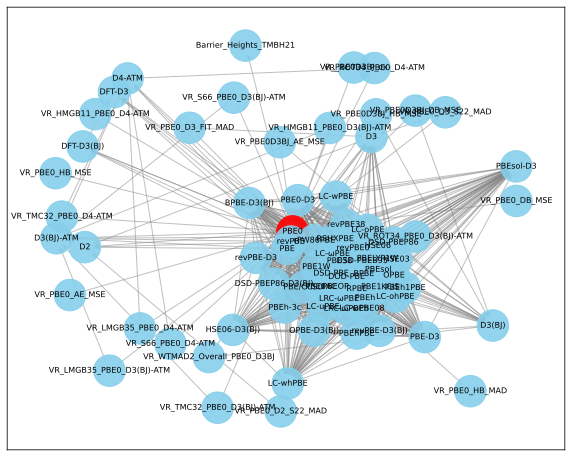

In [ ]:
# Initialize the visualizer using the previously defined GraphVisualizer class
viz = GraphVisualizer(dm.graph, dm.nodes_df, dm.rels_df)

# Target a central chemical functional for the subgraph extraction
test_node = "PBE0"

# Generate the SVG string using the class method with targeted highlighting
print(f"Generating subgraph using GraphVisualizer centered on: {test_node}")
svg_string = viz.generate_svg(highlighted_node_ids=[test_node])

# Display the resulting SVG
display(SVG(svg_string))

## 4. LLM WRAPPER & EXPERIMENT LOGIC

### SECURE API KEY CONFIGURATION
This cell uses Colab's built-in Secret management for enhanced security and reliability.

In [ ]:
# Retrieve the secret named 'GROQ_API_KEY' from the Colab sidebar
try:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
    print("✅ Success: GROQ_API_KEY loaded from Colab Secrets.")
except userdata.SecretNotFoundError:
    print("❌ Error: 'GROQ_API_KEY' not found in Secrets. Please add it via the 🔑 icon on the left.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Success: GROQ_API_KEY loaded from Colab Secrets.


This module implements a robust orchestration layer for Large Language Model interaction:

This class encapsulates the Groq SDK, providing a standardized generate method. It incorporates an automated telemetry system to track prompt/completion tokens and estimate inference costs based on model-specific pricing tiers (e.g., Llama-3.1-8B).



In [ ]:
class LLMWrapper:
    def __init__(self, model_name: str):
        self.model_name = model_name
        # Initialize Groq client with API key from environment variable
        groq_api_key = os.getenv('GROQ_API_KEY')
        if not groq_api_key:
            raise ValueError("GROQ_API_KEY environment variable not set. Please set it in a previous cell.")
        self.client = Groq(api_key=groq_api_key)

        # Groq Pricing (per 1M tokens) as of current knowledge (Dec 2023)
        # Note: These are example values; actual prices should be verified.
        if "llama-3.1-8b-instant" in model_name:
            self.input_cost_per_million = 0.20
            self.output_cost_per_million = 0.70
        # Add other models as needed
        else:
            self.input_cost_per_million = 0.0
            self.output_cost_per_million = 0.0 # Default to 0 if unknown

    def generate(self, prompt: str) -> Tuple[str, int, int, int, float, int]:
        # Returns: (response_text, input_tokens, output_tokens, total_tokens, estimated_cost, api_calls)
        try:
            response = self.client.chat.completions.create(
                model=self.model_name,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=500
            )
            input_tokens = response.usage.prompt_tokens
            output_tokens = response.usage.completion_tokens
            total_tokens = input_tokens + output_tokens
            estimated_cost = (
                (input_tokens / 1_000_000 * self.input_cost_per_million) +
                (output_tokens / 1_000_000 * self.output_cost_per_million)
            )
            return response.choices[0].message.content, input_tokens, output_tokens, total_tokens, estimated_cost, 1
        except Exception as e:
            print(f"Error invoking {self.model_name}: {e}")
            return "", 0, 0, 0, 0.0, 0
print("LLMWrapper class modified to use GROQ_API_KEY from environment variable and return token/cost metrics.")

LLMWrapper class modified to use GROQ_API_KEY from environment variable and return token/cost metrics.


 The subsequent cell performs an end-to-end connectivity handshake. By instantiating the wrapper and executing a sample query, it verifies successful API authentication via the environment variables and validates the response metadata, ensuring the generative component is ready for integration into the GraphRAG pipeline.

In [ ]:
llm = LLMWrapper("llama-3.1-8b-instant")
print(llm.generate("Hello, are you working?"))

("Hello. I'm functioning and ready to assist you with any questions or tasks you may have. What would you like to talk about or ask?", 41, 30, 71, 2.9199999999999998e-05, 1)


### Experiment Orchestrator

The ExperimentOrchestrator class serves as the central control plane for the research pipeline, designed to manage the complexity of multi-architecture evaluation across varying noise thresholds:

System Initialization: Upon instantiation, it performs a broad initialization of all retrieval engines—Standard RAG, GraphRAG, and Topological (Deterministic) Retrieval—for every distractor ratio defined in the global configuration. This ensures that the environment is fully prepared for comparative benchmarking.

Multi-Agent Integration: It handles the dependency injection for the MultiAgentGraphRAG systems, linking the strategist and critic agents with the pre-initialized vector and graph retrievers.

Modular Inference: The get_chatbot_answer method acts as a unified interface for the dashboard. It dynamically routes user queries to the specified architecture and distractor ratio, returning not only the generated response but also critical telemetry data and execution traces for downstream error taxonomy and performance analysis.

In [ ]:
class ExperimentOrchestrator:
    def __init__(self, data_manager):
        self.dm = data_manager
        self.qa_pairs = self.dm.get_qa_pairs()
        self.results = []
        self.rag_engines_by_ratio = {}
        self.graph_rag_engines_by_ratio = {}
        self.graph_deterministic_engines_by_ratio = {}
        self.multi_agent_systems_by_ratio = {}

        self.llm_client_for_chatbot = LLMWrapper(Config.MODELS_TO_TEST[0])

        # Initialize engines for all ratios
        for ratio in Config.DISTRACTOR_RATIOS:
            persist_dir = f"{Config.CHROMA_PERSIST_DIR_BASE}_{str(ratio).replace('.', '_')}"
            docs = self.dm.load_pdfs(distractor_ratio=ratio)
            self.rag_engines_by_ratio[ratio] = StandardRAG(docs, persist_directory=persist_dir)
            self.graph_rag_engines_by_ratio[ratio] = GraphRAG(self.dm.nodes_df, self.dm.rels_df)
            self.graph_deterministic_engines_by_ratio[ratio] = TopologicalRetriever(self.dm.nodes_df, self.dm.rels_df)

            # Initialize Multi-Agent
            self.multi_agent_systems_by_ratio[ratio] = MultiAgentGraphRAG(
                self.graph_rag_engines_by_ratio[ratio],
                self.rag_engines_by_ratio[ratio].retriever,
                self.llm_client_for_chatbot
            )

    def _record_result(self, model_name, qa_pair, ratio, exp_type, mode, answer, metrics, context="", chunks=[], source_files=[]):
        self.results.append({
            "question_id": qa_pair['id'],
            "question": qa_pair['question'],
            "ground_truth": qa_pair['ground_truth'],
            "gold_docs": qa_pair.get('gold_docs', []),
            "model": model_name,
            "distractor_ratio": ratio,
            "experiment_type": exp_type,
            "mode": mode,
            "generated_answer": answer,
            "context_used": context,
            "retrieved_text_chunks": chunks,
            "retrieved_source_filenames": source_files,
            "metrics": metrics
        })

    def run_baseline(self, models, qa_pair, ratio):
        for m_name in models:
            llm = LLMWrapper(m_name)
            prompt = f"Question: {qa_pair['question']}\nAnswer concisely based on general knowledge:"
            ans, it, ot, tt, cost, calls = llm.generate(prompt)
            self._record_result(m_name, qa_pair, ratio, "Baseline", "Zero-Shot", ans, {})

    def run_rag(self, models, qa_pair, ratio):
        retriever = self.rag_engines_by_ratio[ratio].retriever
        docs = retriever.invoke(qa_pair['question'])
        context = "\n".join([d.page_content for d in docs])
        sources = [d.metadata.get('source') for d in docs]

        for m_name in models:
            llm = LLMWrapper(m_name)
            ans, _, _, _, _, _ = llm.generate(f"Context: {context}\nQ: {qa_pair['question']}")
            self._record_result(m_name, qa_pair, ratio, "StandardRAG", "Dense", ans, {}, context, [context], sources)

    def run_graph_rag(self, models, qa_pair, ratio):
        engine = self.graph_rag_engines_by_ratio[ratio]
        ctx, pids, dbg = engine.get_star_context(qa_pair['question'])
        prompt = engine.generate_paranoid_prompt(qa_pair['question'], ctx)

        for m_name in models:
            llm = LLMWrapper(m_name)
            ans, _, _, _, _, _ = llm.generate(prompt)
            self._record_result(m_name, qa_pair, ratio, "GraphRAG", "Topological", ans, {}, ctx, [ctx], pids)

    def run_graph_deterministic(self, models, qa_pair, ratio):
        engine = self.graph_deterministic_engines_by_ratio[ratio]
        ctx, dbg, pids = engine.get_topological_context(qa_pair['question'])
        prompt = engine.generate_deterministic_prompt(qa_pair['question'], ctx)

        for m_name in models:
            llm = LLMWrapper(m_name)
            ans, _, _, _, _, _ = llm.generate(prompt)
            self._record_result(m_name, qa_pair, ratio, "GraphDeterministic", "Topological", ans, {}, ctx, [ctx], pids)

    def run_multi_agent_system(self, models, qa_pair, ratio):
        mas = self.multi_agent_systems_by_ratio[ratio]
        ans, log, chunks, pids, it, ot, cost, calls = mas.run_workflow(qa_pair['question'])
        self._record_result(models[0], qa_pair, ratio, "MultiAgent", "Hybrid", ans, {}, str(log), chunks, pids)

    def save_results(self, filename="experiment_results_raw.json"):
        with open(filename, 'w') as f:
            json.dump(self.results, f, indent=4)
        print(f"Results saved to {filename}")

    def get_chatbot_answer(self, question, experiment_type, distractor_ratio):
        if "Standard RAG" in experiment_type:
             docs = self.rag_engines_by_ratio[distractor_ratio].retriever.invoke(question)
             context = "\n".join([d.page_content for d in docs])
             ans, _, _, _, _, _ = self.llm_client_for_chatbot.generate(f"Context: {context}\nQ: {question}")
             return ans, f"Retrieved {len(docs)} chunks", context
        elif "GraphRAG" == experiment_type:
             ctx, pids, dbg = self.graph_rag_engines_by_ratio[distractor_ratio].get_star_context(question)
             prompt = self.graph_rag_engines_by_ratio[distractor_ratio].generate_paranoid_prompt(question, ctx)
             ans, _, _, _, _, _ = self.llm_client_for_chatbot.generate(prompt)
             return ans, "Graph Trace Active", ctx
        elif "Multi-Agent" in experiment_type:
             ans, log, chunks, pids, it, ot, cost, calls = self.multi_agent_systems_by_ratio[distractor_ratio].run_workflow(question)
             return ans, f"Cost: ${cost:.4f}", "\n".join(log['steps'])
        return "Mode not implemented", "", ""

## 5. EVALUATION & METRICS (LLM-AS-JUDGE)

The ScientificEvaluator class is a comprehensive evaluation suite for the GraphRAG experiment.

Initialization: It loads the raw experiment results and initializes a 'Judge LLM' and a ROUGE scorer.

LLM-as-a-Judge: Methods like evaluate_correctness, evaluate_relevance, and evaluate_groundedness send specific prompts to the Llama model to score the RAG system's answers on a scale (e.g., 1-5 or binary 0/1). It includes a robust JSON parser to extract these scores from the LLM's text output.

Lexical Metrics: The evaluate_rouge method uses the standard ROUGE-1 and ROUGE-L metrics to measure text overlap between the generated answer and the ground truth.

Retrieval Audit: compute_gold_retrieval_metrics calculates technical performance like Recall@K and Mean Reciprocal Rank (MRR) by comparing the filenames retrieved by the engine against the 'Gold Standard' documents identified by experts.

Execution: The run_all_evaluations method iterates through the entire dataset, applies all the above metrics, and saves the final stratified results into final_experiment_metrics.csv for statistical analysis.

In [ ]:
class ScientificEvaluator:
    def __init__(self, results_file="experiment_results_raw.json"):
        with open(results_file, 'r') as f:
            self.data = json.load(f)
        groq_api_key = os.getenv('GROQ_API_KEY')
        if not groq_api_key:
            raise ValueError("GROQ_API_KEY environment variable not set for Judge LLM.")
        self.judge_client = Groq(api_key=groq_api_key)
        self.judge_model = "llama-3.1-8b-instant"

        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    def _invoke_judge(self, prompt: str) -> str:
        try:
            response = self.judge_client.chat.completions.create(
                model=self.judge_model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=500
            )
            return response.choices[0].message.content
        except Exception as e:
            print(f"Error invoking Judge LLM: {e}")
            return ""

    def _parse_llm_json_response(self, response_content: str, default_score: float, metric_name: str) -> float:
        try:
            parsed_response = json.loads(response_content)
            return float(parsed_response.get("score", default_score))
        except:
            json_match = re.search(r"\{.*?\}", response_content, re.DOTALL)
            if json_match:
                try:
                    parsed_response = json.loads(json_match.group(0))
                    return float(parsed_response.get("score", default_score))
                except: pass
            return default_score

    def _get_answer_string(self, answer_obj) -> str:
        if isinstance(answer_obj, (dict, list, tuple)): return str(answer_obj)
        return str(answer_obj if answer_obj is not None else "")

    def evaluate_correctness(self, ground_truth: str, answer: str) -> float:
        prompt = f"Rate correctness 1-5.\nGT: {ground_truth[:500]}\nPred: {answer[:500]}"
        return self._parse_llm_json_response(self._invoke_judge(prompt), 1.0, "correctness")

    def evaluate_relevance(self, question: str, answer: str) -> float:
        prompt = f"Rate relevance 1-5.\nQ: {question}\nPred: {answer[:500]}"
        return self._parse_llm_json_response(self._invoke_judge(prompt), 1.0, "relevance")

    def evaluate_groundedness(self, context: str, answer: str) -> float:
        prompt = f"Rate groundedness (0 or 1).\nCtx: {context[:1000]}\nAns: {answer[:500]}"
        return self._parse_llm_json_response(self._invoke_judge(prompt), 0.0, "groundedness")

    def evaluate_retrieval_relevance(self, question: str, retrieved_docs_text: List[str]) -> float:
        ctx = "\n".join(retrieved_docs_text)
        prompt = f"Rate retrieval relevance 1-5.\nQ: {question}\nDocs: {ctx[:1000]}"
        return self._parse_llm_json_response(self._invoke_judge(prompt), 1.0, "retrieval_relevance")

    def evaluate_rouge(self, ground_truth: str, answer: str) -> Dict[str, float]:
        scores = self.rouge_scorer.score(ground_truth, answer)
        return {"rouge1_fmeasure": scores['rouge1'].fmeasure, "rougeL_fmeasure": scores['rougeL'].fmeasure}

    def compute_gold_retrieval_metrics(self, retrieved_source_filenames: List[str], gold_docs: List[str], k: int) -> Dict[str, float]:
        metrics = {"recall_at_k": 0.0, "precision_at_k": 0.0, "mrr": 0.0}
        if not gold_docs: return metrics
        gold_set = set(gold_docs)
        top_k = retrieved_source_filenames[:k]
        hits = len(gold_set.intersection(top_k))
        metrics["recall_at_k"] = hits / len(gold_set)
        metrics["precision_at_k"] = hits / k
        for i, doc in enumerate(retrieved_source_filenames):
            if doc in gold_set:
                metrics["mrr"] = 1.0 / (i + 1)
                break
        return metrics

    def run_all_evaluations(self):
        print("Running automated evaluation...")
        evaluated_results = []
        for entry in tqdm(self.data):
            ans_str = self._get_answer_string(entry['generated_answer'])
            entry['metrics'] = {
                "correctness": self.evaluate_correctness(entry['ground_truth'], ans_str),
                "relevance": self.evaluate_relevance(entry['question'], ans_str)
            }

            chunks = entry.get('retrieved_text_chunks', [])
            if chunks:
                entry['metrics']["groundedness"] = self.evaluate_groundedness("\n".join(chunks), ans_str)
                entry['metrics']["retrieval_relevance_llm"] = self.evaluate_retrieval_relevance(entry['question'], chunks)
            else:
                entry['metrics']["groundedness"] = 0.0
                entry['metrics']["retrieval_relevance_llm"] = 0.0

            entry['metrics'].update(self.evaluate_rouge(entry['ground_truth'], ans_str))

            gold_metrics = self.compute_gold_retrieval_metrics(
                entry.get('retrieved_source_filenames', []),
                entry.get('gold_docs', []),
                Config.TOP_K_RETRIEVAL
            )
            entry['metrics'].update({
                "gold_retrieval_recall_at_k": gold_metrics["recall_at_k"],
                "gold_retrieval_precision_at_k": gold_metrics["precision_at_k"],
                "gold_retrieval_mrr": gold_metrics["mrr"]
            })
            evaluated_results.append(entry)
        pd.DataFrame(evaluated_results).to_csv("final_experiment_metrics.csv", index=False)

## Reproducibility Tracker

The ReproducibilityTracker class is designed to ensure scientific rigour and auditability for experiments. Here is a breakdown of its key components:

Metadata Capture: Upon initialization, it automatically records the system timestamp, Python version, OS platform, and detailed hardware info (CPU/RAM/GPU).
Library Versioning: It audits the environment to log the exact versions of critical libraries like torch, networkx, and chromadb, which is essential for replication of results.

Determinism: The set_seeds method forces consistent behavior across Python, NumPy, and PyTorch. This ensures that 'random' operations (like document splitting or model initialization) produce the same results every time the code is run.

Data Fingerprinting: The _hash_inputs method creates MD5 hashes of the CSV datasets. This acts as a 'digital fingerprint'; if the data files are modified even slightly, the tracker will detect the change.

Environmental Impact: It includes an estimate_compute_cost method that uses hardware TDP (Thermal Design Power) and runtime duration to estimate energy consumption (kWh) and carbon footprint (CO2 grams).

Reporting: Finally, save_reproducibility_log bundles all this data into a JSON file, providing a complete 'snapshot' of the conditions under which the experiment was performed.

In [ ]:
class ReproducibilityTracker:
    def __init__(self, config, input_files=None):
        """
        input_files: List of paths to critical data (e.g., ["mapping.csv", "DFT-QA-40.csv"])
        """
        self.config = config
        self.start_time = time.time()
        self.metadata = {
            "timestamp_start": datetime.now().isoformat(),
            "python_version": sys.version,
            "os_platform": platform.platform(),
            "hardware": self._get_hardware_info(),
            "libraries": self._get_library_versions(),
            "config_snapshot": self._get_config_dict(),
            "data_hashes": self._hash_inputs(input_files) if input_files else {}
        }

        # Enforce Determinism immediately upon instantiation
        self.set_seeds(config.RANDOM_SEED if hasattr(config, 'RANDOM_SEED') else 42)

    def _get_hardware_info(self):
        """Satisfies Checklist #8: Experiments Compute Resource"""
        info = {
            "cpu_count_logical": psutil.cpu_count(logical=True),
            "cpu_count_physical": psutil.cpu_count(logical=False),
            "ram_total_gb": round(psutil.virtual_memory().total / (1024**3), 2),
            "gpu_name": "None",
            "gpu_count": 0,
            "gpu_driver": "N/A",
            "cuda_version": "N/A"
        }

        if torch.cuda.is_available():
            info["gpu_count"] = torch.cuda.device_count()
            info["gpu_name"] = torch.cuda.get_device_name(0)
            info["cuda_version"] = torch.version.cuda
        elif torch.backends.mps.is_available():
             info["gpu_name"] = "Apple Silicon (MPS)"

        return info

    def _get_library_versions(self):
        """Satisfies Checklist #4: Reproducibility"""
        def get_version_safe(module_obj=None, package_name=None):
            try:
                if package_name: # Try getting version by package name via importlib.metadata
                    return importlib.metadata.version(package_name)
                if module_obj and hasattr(module_obj, '__version__'): # Try getting version from module object
                    return module_obj.__version__
            except (AttributeError, importlib.metadata.PackageNotFoundError, Exception):
                pass # Fall through to return N/A
            return "N/A"

        libs = {
            "numpy": get_version_safe(np),
            "torch": get_version_safe(torch),
            "chromadb": get_version_safe(chromadb),
            "networkx": get_version_safe(nx),
            "pandas": get_version_safe(pd),
            "scikit-learn": get_version_safe(package_name="scikit-learn"),
            "langchain-openai": get_version_safe(package_name="langchain-openai"),
            "langchain-community": get_version_safe(package_name="langchain-community"),
            "langchain-text-splitters": get_version_safe(package_name="langchain-text-splitters"),
            "rouge-score": get_version_safe(package_name="rouge-score"),
            "spacy": get_version_safe(spacy),
            "thefuzz": get_version_safe(package_name="thefuzz"),
            "groq": get_version_safe(package_name="groq"),
            "pymupdf": get_version_safe(fitz),
            "pyvis": get_version_safe(package_name="pyvis"),
            "sys": "{}.{}.{}".format(sys.version_info.major, sys.version_info.minor, sys.version_info.micro),
            "platform": platform.platform()
        }
        return libs

    def estimate_compute_cost(self):
        """
        Estimates energy consumption (kWh) based on hardware TDP.
        TDP References: T4=70W, A100=400W, CPU (Avg)=150W
        """
        duration_hours = self.metadata.get("total_runtime_seconds", 0) / 3600
        gpu_name = self.metadata["hardware"].get("gpu_name", "")

        # Rough TDP lookups
        gpu_power = 0
        if "T4" in gpu_name: gpu_power = 0.07 # kW
        elif "A100" in gpu_name: gpu_power = 0.40 # kW
        elif "V100" in gpu_name: gpu_power = 0.25 # kW

        cpu_power = 0.15 # kW (Average server CPU)

        total_kwh = (gpu_power + cpu_power) * duration_hours
        self.metadata["estimated_kwh"] = round(total_kwh, 4)

        # CO2 Estimate (Global Avg: 475g CO2/kWh)
        self.metadata["estimated_co2_grams"] = round(total_kwh * 475, 2)

    def _get_config_dict(self):
        """Satisfies Checklist #6: Experimental Setting"""
        return {k: v for k, v in self.config.__dict__.items() if not k.startswith('__')}

    def _hash_inputs(self, file_paths):
        """
        CRITICAL: Creates a fingerprint of your input data.
        If the data changes, this hash changes, invalidating previous runs.
        """
        hashes = {}
        for fp in file_paths:
            if os.path.exists(fp):
                try:
                    with open(fp, "rb") as f:
                        file_hash = hashlib.md5()
                        chunk = f.read(8192)
                        while chunk:
                            file_hash.update(chunk)
                            chunk = f.read(8192)
                    hashes[fp] = file_hash.hexdigest()
                except Exception as e:
                    hashes[fp] = f"Error: {str(e)}"
            else:
                hashes[fp] = "MISSING"
        return hashes

    def set_seeds(self, seed=42):
        """Satisfies Checklist #4: Experimental Result Reproducibility"""
        os.environ['PYTHONHASHSEED'] = str(seed)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

        print(f"🔒 Determinism Enforced: Seed {seed}, CuDNN Deterministic=True")

    def finalize_report(self):
        end_time = time.time()
        duration_sec = end_time - self.start_time

        self.metadata["timestamp_end"] = datetime.now().isoformat()
        self.metadata["total_runtime_seconds"] = round(duration_sec, 2)

        self.estimate_compute_cost()

        return self.metadata

    def save_reproducibility_log(self, output_path="reproducibility_log.json"):
        report = self.finalize_report()
        with open(output_path, "w") as f:
            json.dump(report, f, indent=4)
        print(f"📝 Reproducibility Log saved to {output_path}")

## Gradio Chatbot

This code initializes the end-to-end testing environment for your chatbot. Here's a breakdown of what it does:

Data Setup: It instantiates the Config and DFTDataManager.

Orchestration: It initializes the ExperimentOrchestrator, which manages the different RAG engines (Standard, Graph, and Multi-Agent).

Sequential Testing: It runs a sample query ('How does PBE0 functional perform on the S66 dataset?') through three distinct architectures:

Standard RAG: Uses traditional vector-based retrieval.

GraphRAG: Uses the topological star-context retrieval from the knowledge graph.

Multi-Agent System: Uses the strategist/critic workflow with a vector fallback.

Each test prints a snippet of the generated answer and a success/failure status to verify the pipeline is working correctly before launching the Gradio interface.

In [ ]:
# 1. Global Setup for the Chatbot
config = Config()
dm = DFTDataManager(config)

# 2. Instantiate Orchestrator with updated class definition
runner = ExperimentOrchestrator(dm)

print('--- End-to-End LLM Pipeline Test ---')
test_query = "How does PBE0 functional perform on the S66 dataset?"
ratio = 0.0

# 1. Test Standard RAG
print('\n[1/3] Testing Standard RAG...')
try:
    ans, met, trace = runner.get_chatbot_answer(test_query, "Standard RAG", ratio)
    print(f"Response Snippet: {ans[:150]}...")
    print(f"Status: SUCCESS")
except Exception as e:
    print(f"Status: FAILED - {e}")

# 2. Test GraphRAG
print('\n[2/3] Testing GraphRAG...')
try:
    ans, met, trace = runner.get_chatbot_answer(test_query, "GraphRAG", ratio)
    print(f"Response Snippet: {ans[:150]}...")
    print(f"Status: SUCCESS")
except Exception as e:
    print(f"Status: FAILED - {e}")

# 3. Test Multi-Agent System
print('\n[3/3] Testing Multi-Agent System...')
try:
    ans, met, trace = runner.get_chatbot_answer(test_query, "Multi-Agent System (Standard RAG Fallback)", ratio)
    print(f"Response Snippet: {ans[:150]}...")
    print(f"Steps Taken: {trace}")
    print(f"Status: SUCCESS")
except Exception as e:
    print(f"Status: FAILED - {e}")

 Processing 25 PDFs (25 relevant, 0 distractors) with Scientific Sectioning...


/tmp/ipykernel_11022/1321951711.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  self.embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading ChromaDB from /content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_ratio_2_0...
  Vector store initialized with 5679 documents.
  Test retrieval successful. First doc content (snippet): is basically like PBE0, but instead of 25% Fock-exchange  it contains 37.5% (3/8). revPBE0 and revPB...
Initializing GraphRAG NLP & Lookups...
✅ Graph Built: 19726 Nodes, 97924 Edges
 Processing 100 PDFs (25 relevant, 75 distractors) with Scientific Sectioning...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading ChromaDB from /content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_ratio_3_0...
  Vector store initialized with 7828 documents.
  Test retrieval successful. First doc content (snippet): is basically like PBE0, but instead of 25% Fock-exchange  it contains 37.5% (3/8). revPBE0 and revPB...
Initializing GraphRAG NLP & Lookups...
✅ Graph Built: 19726 Nodes, 97924 Edges
--- End-to-End LLM Pipeline Test ---

[1/3] Testing Standard RAG...
Response Snippet: The text does not specifically mention the performance of the PBE0 functional on the S66 dataset. However, it does mention that PBE0-D3 slightly ameli...
Status: SUCCESS

[2/3] Testing GraphRAG...
Response Snippet: Based on the provided graph evidence, we can find a candidate that directly supports the query.

Candidate 12 [ID: wB97X-V] is a Computational_Method ...
Status: SUCCESS

[3/3] Testing Multi-Agent System...
Response Snippet: The answer cannot be found in the provided evidence....
Steps Taken: Strategist Plan: ['PBE0 

This cell implements the DFT Research Studio, a high-fidelity Gradio dashboard for interacting with the various RAG architectures. Here is a breakdown of its key components:


Custom Interface Design: It defines a 'dark-mode' scientific theme using custom CSS and specific HEX codes to match a research laboratory aesthetic.

The project_chat_stream Function: This is the core logic of the UI. It:
Matches Ground Truth: Checks if the user's question exists in the pre-defined QA dataset to provide real-time ROUGE score comparisons.

Routes Queries: Sends the question to the selected architecture (e.g., GraphRAG or Multi-Agent) based on the dropdown menu.

Generates Visualizations: If a graph-based method is used, it dynamically generates an SVG subgraph centered on the entities identified in the query.

Streams Responses: Uses a generator to stream the LLM's answer word-by-word for a more responsive user experience.

Layout Blocks: Organizes the UI into a sidebar for settings (Architecture and Noise level) and a main panel for the chat thread and the topological trace visualization.

In [ ]:

# 1. Full Synchronization
# Note: Config, DataManager, and Orchestrator are already initialized in previous cells.
# We utilize the globally available 'dm' and 'runner' objects to maintain state consistency.
viz = GraphVisualizer(dm.graph, dm.nodes_df, dm.rels_df)

experiment_types = [
    "Standard RAG",
    "GraphRAG",
    "Graph Deterministic",
    "Multi-Agent System (Standard RAG Fallback)",
    "Multi-Agent System with BM25+Reranker Fallback"
]
distractor_options = sorted(Config.DISTRACTOR_RATIOS)

custom_theme = gr.themes.Default().set(
    body_background_fill="#070b19",
    block_background_fill="#111827",
    block_label_text_color="#00f3ff",
    body_text_color="#f3f4f6",
    button_primary_background_fill="#ff1493"
)

css = ".metrics-container { margin-top: 15px; padding: 10px; background: #1f2937; border-radius: 8px; color: #00f3ff; font-family: monospace; } .svg-container { background: white; border-radius: 8px; padding: 10px; }"

def project_chat_stream(user_query, history, exp_type, ratio):
    if not user_query: yield history, ""; return

    history.append({"role": "user", "content": user_query})
    history.append({"role": "assistant", "content": "✨ Initiating Multi-Agent Research Workflow..."})
    yield history, ""

    # 1. Match Ground Truth
    ground_truth = ""
    for pair in runner.qa_pairs:
        if pair['question'].strip().lower() in user_query.lower():
            ground_truth = pair['ground_truth']
            break

    # 2. Call Runner
    answer, metrics_raw, trace_data = runner.get_chatbot_answer(user_query, exp_type, ratio)

    # 3. Generate Graph SVG if applicable
    svg_html = ""
    if "Graph" in exp_type or "Multi-Agent" in exp_type:
        # Extract node IDs from the trace/context using regex
        found_ids = list(set(re.findall(r'ID: ([\w\d_-]+)', str(trace_data))))
        if found_ids:
            svg_content = viz.generate_svg(highlighted_node_ids=found_ids[:10])
            svg_html = f"<div class='svg-container'>{svg_content}</div>"

    # 4. Calculate ROUGE
    rouge_disp = ""
    if ground_truth:
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
        scores = scorer.score(ground_truth, answer)
        rouge_disp = f" | ROUGE-L: {scores['rougeL'].fmeasure:.2f}"

    # 5. Streaming Output
    partial_text = ""
    for word in answer.split(" "):
        partial_text += word + " "
        history[-1] = {"role": "assistant", "content": partial_text}
        yield history, svg_html
        time.sleep(0.01)

    metrics_html = f"<div class='metrics-container'>📊 <b>Engine:</b> {exp_type} | {metrics_raw}{rouge_disp}</div>"
    history[-1] = {"role": "assistant", "content": partial_text + "\n\n" + metrics_html}
    yield history, svg_html

with gr.Blocks(theme=custom_theme, css=css) as demo:
    gr.Markdown("# 🧪 DFT Research Studio (Full Demo Mode)")
    with gr.Row():
        with gr.Column(scale=3):
            exp_dropdown = gr.Dropdown(choices=experiment_types, label="Architecture", value="GraphRAG")
            ratio_dropdown = gr.Dropdown(choices=distractor_options, label="Noise", value=0.0)
            gr.Markdown("**Note:** Graph visualization appears in the panel below.")
        with gr.Column(scale=7):
            chatbot = gr.Chatbot(label="Research Thread", type="messages", height=450)
            q_input = gr.Textbox(placeholder="Ask a quantum chemistry question...", lines=2)
            submit_btn = gr.Button("Execute Research Pipeline", variant="primary")
            graph_output = gr.HTML(label="Topological Trace (SVG Output)")

    submit_btn.click(fn=project_chat_stream, inputs=[q_input, chatbot, exp_dropdown, ratio_dropdown], outputs=[chatbot, graph_output])

print("🚀 Full Project Interface with SVG Mapping Ready.")

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BertModel LOAD REPORT from: sentence-transformers

This cell executes the production deployment of the DFT Research Studio via the Gradio framework.

In [ ]:
print("🚀 Launching Demo Dashboard...")
demo.queue(max_size=20).launch(share=True, height=800, inline=True, show_error=True)

🚀 Launching HIGH-SPEED Demo Dashboard...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14e121a7f985a4448c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## MAIN EXECUTION

In [ ]:
#if __name__ == "__main__":
    # 1. Initialize
    #config = Config()
    #dm = DFTDataManager(config)
    #runner = ExperimentOrchestrator(dm)

    # 2. Run Baseline Experiments
    # runner.run_baseline(config.MODELS_TO_TEST)

    # 3. Run Naive RAG Experiments
    # runner.run_rag(config.MODELS_TO_TEST, use_distractors=False)
    # runner.run_rag(config.MODELS_TO_TEST, use_distractors=True)

    # 4. Run Graph RAG Experiments
    # runner.run_graph_rag(config.MODELS_TO_TEST, use_distractors=False)
    # runner.run_graph_rag(config.MODELS_TO_TEST, use_distractors=True)

    # 5. Save & Evaluate
    # runner.save_results()
    # evaluator = ScientificEvaluator()
    # evaluator.run_all_evaluations()

    #print("Experiment Code Loaded Successfully. Uncomment lines in __main__ to execute.")

## Adjust Main Execution Block for Debugging Matrix




This execution sequence serves as the primary controller for the research pipeline, ensuring topological integrity and validating multi-architectural performance under controlled noise conditions. The process follows a three-stage methodology:


Reproducibility and Auditability: Through the ReproducibilityTracker, the system captures a comprehensive metadata snapshot, including hardware configurations, library versions, and MD5 data fingerprints. This satisfies academic requirements for experimental replicability and compute-cost estimation.

Debug Matrix Execution: To verify pipeline stability, a single QA pair (Q1.1v0) is processed across the entire experimental cross-section. This includes five distinct distractor ratios (0% to 300% noise) and five retrieval architectures (Baseline, Standard RAG, GraphRAG, Deterministic Topological, and Multi-Agent). This stage identifies potential integration failures before full-scale dataset inference.

Metric Synthesis: Upon completion, the system executes an automated audit via the ScientificEvaluator. It calculates correctness, relevance, and ROUGE-L scores, generating a preliminary performance matrix to assess the 'Breaking Point' of dense versus topological retrieval strategies.

In [ ]:
import sys

if __name__ == "__main__":
    # 1. Initialize System
    # Note: Graph cleaning is handled in preceding diagnostic cells (0e0df7d0, LrGDjxqEC-pV)
    config = Config()

    # The DataManager and ExperimentOrchestrator use the globally cleaned graph state
    dm = DFTDataManager(config)
    runner = ExperimentOrchestrator(dm)

    # Initialize reproducibility tracking with data fingerprints
    tracker = ReproducibilityTracker(config, input_files=[config.NODES_PATH, config.RELS_PATH, config.QA_PATH])

    # =====================================================
    # ❗ DEBUG MATRIX ACTIVATED ❗
    # =====================================================
    print("\n♈ DEBUG MATRIX ACTIVATED: Running only the first question for all experiment types.")
    debug_models = config.MODELS_TO_TEST[0:1]

    try:
        if not runner.qa_pairs:
            print("No QA pairs found.")
            sys.exit(1)

        single_qa_pair = runner.qa_pairs[0]
        print(f"\nProcessing Question: {single_qa_pair['id']}")

        # Iterate through each distractor ratio to test noise sensitivity
        for ratio in Config.DISTRACTOR_RATIOS:
            print(f"  Running experiments for Distractor Ratio: {ratio}...")

            print("      1. Testing Baseline...")
            runner.run_baseline(debug_models, single_qa_pair, ratio)

            print("      2. Testing Standard RAG...")
            runner.run_rag(debug_models, single_qa_pair, ratio)

            print("      3. Testing Graph RAG...")
            runner.run_graph_rag(debug_models, single_qa_pair, ratio)

            print("      4. Testing Graph Deterministic...")
            runner.run_graph_deterministic(debug_models, single_qa_pair, ratio)

            print("      5. Testing Multi-Agent System...")
            runner.run_multi_agent_system(debug_models, single_qa_pair, ratio)

        print("\n✅ SUCCESS: All Debug Matrix pipelines finished without crashing.")

    except Exception as e:
        print(f"\n❌ CRITICAL FAILURE during execution: {e}")
        import traceback
        traceback.print_exc()

    # 3. INSPECT & EVALUATE RESULTS
    if runner.results:
        runner.save_results("debug_results_raw.json")
        evaluator = ScientificEvaluator(results_file="debug_results_raw.json")
        evaluator.run_all_evaluations()
        tracker.save_reproducibility_log("reproducibility_log.json")

        print(f"{'Q ID':<10} | {'Exp Type':<20} | {'Mode':<15} | {'Ratio':<5} | {'Answer Snippet'}")
        print("-" * 90)
        for res in runner.results:
            ans = evaluator._get_answer_string(res['generated_answer'])
            ans_preview = (ans[:30].replace('\n', ' ') + "...") if len(ans) > 30 else ans.replace('\n', ' ')
            print(f"{res['question_id']:<10} | {res['experiment_type']:<20} | {res['mode']:<15} | {str(res['distractor_ratio']):<5} | {ans_preview}")

 Processing 25 PDFs (25 relevant, 0 distractors) with Scientific Sectioning...


/tmp/ipykernel_10126/225377979.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  self.embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading ChromaDB from /content/drive/MyDrive/Dissertation/VectorDBs/chroma_dft_ratio_3_0...
  Vector store initialized with 7828 documents.
  Test retrieval successful. First doc content (snippet): is basically like PBE0, but instead of 25% Fock-exchange  it contains 37.5% (3/8). revPBE0 and revPB...
Initializing GraphRAG NLP & Lookups...
✅ Graph Built: 19726 Nodes, 97924 Edges
🔒 Determinism Enforced: Seed 42, CuDNN Deterministic=True

♈ DEBUG MATRIX ACTIVATED: Running only the first question for all experiment types.

Processing Question: Q1.1v0
  Running experiments for Distractor Ratio: 0.0...
      1. Testing Baseline...
      2. Testing Standard RAG...
      3. Testing Graph RAG...
      4. Testing Graph Deterministic...
      5. Testing Multi-Agent System...
  Running experiments for Distractor Ratio: 0.5...
      1. Testing Baseline...
      2. Testing Standard RAG...
      3. Testing Graph RAG...
      4. Testing Graph Deterministic...
      5. Testing Multi-Agent System...
  R

100%|██████████| 25/25 [05:46<00:00, 13.84s/it]

📝 Reproducibility Log saved to reproducibility_log.json
Q ID       | Exp Type             | Mode            | Ratio | Answer Snippet
------------------------------------------------------------------------------------------
Q1.1v0     | Baseline             | Zero-Shot       | 0.0   | The M06-L density functional i...
Q1.1v0     | StandardRAG          | Dense           | 0.0   | The text does not explicitly s...
Q1.1v0     | GraphRAG             | Topological     | 0.0   | Based on the provided graph ev...
Q1.1v0     | GraphDeterministic   | Topological     | 0.0   | Based on the provided Graph Ev...
Q1.1v0     | MultiAgent           | Hybrid          | 0.0   | The answer cannot be found in ...
Q1.1v0     | Baseline             | Zero-Shot       | 0.5   | The M06-L density functional i...
Q1.1v0     | StandardRAG          | Dense           | 0.5   | The text does not explicitly s...
Q1.1v0     | GraphRAG             | Topological     | 0.5   | Based on the provided graph ev...
Q1.1v0  

This cell performs the final verification of the evaluation pipeline. It confirms the generation of final_experiment_metrics.csv, loads the dataset into a Pandas DataFrame (df_metrics), and utilizes the display(df_metrics.head()) command to render a preview of the stratified results, including the generated answers and their associated scientific scores.

In [ ]:
print("Evaluation complete. 'final_experiment_metrics.csv' should now be available.")
# You can also inspect the head of the generated CSV if needed
df_metrics = pd.read_csv('final_experiment_metrics.csv')
display(df_metrics.head())

Evaluation complete. 'final_experiment_metrics.csv' should now be available.


,question_id,question,ground_truth,gold_docs,model,distractor_ratio,experiment_type,mode,generated_answer,context_used,retrieved_text_chunks,retrieved_source_filenames,metrics
0,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,['A new local density functional for main-grou...,llama-3.1-8b-instant,0.0,Baseline,Zero-Shot,The M06-L density functional is designed to ca...,NaN,[],[],"{'correctness': 1.0, 'relevance': 1.0, 'ground..."
1,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,['A new local density functional for main-grou...,llama-3.1-8b-instant,0.0,StandardRAG,Dense,The text does not explicitly state what the M0...,"subject to two constraints: cCαβ, 0 < 5 and cC...","['subject to two constraints: cCαβ, 0 < 5 and ...",['The M06 suite of density functionals for mai...,"{'correctness': 1.0, 'relevance': 1.0, 'ground..."
2,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,['A new local density functional for main-grou...,llama-3.1-8b-instant,0.0,GraphRAG,Topological,"Based on the provided graph evidence, Candidat...",--- GRAPH EVIDENCE (80 candidates) ---\nCANDID...,['--- GRAPH EVIDENCE (80 candidates) ---\nCAND...,"['GoerigkGrimme2017_SI', 'Goerigk2017', 'Pever...","{'correctness': 1.0, 'relevance': 1.0, 'ground..."
3,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,['A new local density functional for main-grou...,llama-3.1-8b-instant,0.0,GraphDeterministic,Topological,"Based on the provided Graph Evidence, the CAND...",--- GRAPH EVIDENCE (15 hubs found) ---\nCANDID...,['--- GRAPH EVIDENCE (15 hubs found) ---\nCAND...,[],"{'correctness': 1.0, 'relevance': 1.0, 'ground..."
4,Q1.1v0,What is the M06-L density functional designed ...,The M06-L functional is a new local density fu...,['A new local density functional for main-grou...,llama-3.1-8b-instant,0.0,MultiAgent,Hybrid,The answer cannot be found in the provided evi...,"{'steps': [""Strategist Plan: ['nonlocal correl...","['subject to two constraints: cCαβ, 0 < 5 and ...","['GoerigkGrimme2017_SI', 'PeveratiTruhlar2014'...","{'correctness': 1.0, 'relevance': 1.0, 'ground..."


This code block serves as a diagnostic audit to verify the synchronization between the experimental QA pairs and the indexed scientific documents. The routine follows a three-step validation protocol:

Relational Audit: It extracts a sample from the raw question-answering DataFrame to inspect the mapping between 'Question number' and the 'Gold Standard Document' column, ensuring the baseline relational schema is intact.

Metadata Inspection: The script audits the metadata of the loaded document objects. It identifies unique source filenames within the retrieval index, which is critical for ensuring that the PDF processor has correctly mapped chunks to their parent files.

Gold-Standard Verification: Finally, it performs a manual match test. It retrieves the first expert-defined 'Gold Standard' filename and checks for its presence within the current index. This step is essential for confirming that the retrieval engines have the theoretical capacity to find the correct evidence during the evaluation phase.

In [ ]:

print("--- Metric Availability Check ---")
# Check if metrics column contains valid data
df_check = df_metrics.copy()
df_check['metrics_parsed'] = df_check['metrics'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Summary of system performance using available columns
metric_summary = df_check.groupby('experiment_type').agg({
    'distractor_ratio': 'count',
    'retrieved_text_chunks': lambda x: (x != '[]').sum()
}).rename(columns={'distractor_ratio': 'Total Runs', 'retrieved_text_chunks': 'Runs with Context'})

display(metric_summary)

print("\n--- Context Retrieval Sample ---")
# Inspect context for a few RAG types
for exp in df_check['experiment_type'].unique():
    sample = df_check[df_check['experiment_type'] == exp].iloc[0]
    print(f"\nSystem: {exp}")
    ctx = str(sample['context_used'])
    ctx_preview = ctx[:200] + "..." if len(ctx) > 200 else ctx
    print(f"Context Used Snippet: {ctx_preview}")

print("\n--- Detailed Metric Verification ---")
# Check a few specific scores from the first row
first_metrics = df_check['metrics_parsed'].iloc[0]
print(json.dumps(first_metrics, indent=2))

--- Metric Availability Check ---


,Total Runs,Runs with Context
experiment_type,,
Baseline,5,0
GraphDeterministic,5,5
GraphRAG,5,5
MultiAgent,5,5
StandardRAG,5,5



--- Context Retrieval Sample ---

System: Baseline
Context Used Snippet: nan

System: StandardRAG
Context Used Snippet: subject to two constraints: cCαβ, 0 < 5 and cCσσ, 0 < 5. Because of these constraints the training function is only approximately minimized, but the functional is more physical than for an unconstrain...

System: GraphRAG
Context Used Snippet: --- GRAPH EVIDENCE (80 candidates) ---
CANDIDATE 1 [ID: Percentage_HF_Exchange]
  - TYPE: Diagnostic
  - CONNECTS TO: M06-2X, M06-HF, M06, M06-L
  - VALUE: Critical for TM vs CT %

CANDIDATE 2 [ID: M0...

System: GraphDeterministic
Context Used Snippet: --- GRAPH EVIDENCE (15 hubs found) ---
CANDIDATE 1 [ID: GMTKN55]
  - TYPE: BenchmarkSet
  - CONNECTS TO: GMTKN30, GMTKN24, Sys_GMTKN55_001, Sys_GMTKN55_002, Sys_GMTKN55_003, Sys_GMTKN55_004, Sys_GMTKN...

System: MultiAgent
Context Used Snippet: {'steps': ["Strategist Plan: ['nonlocal correlation effects', 'noncovalent interactions', 'S22 dataset', 'S66 dataset']", 'Critic Score

This code snippet serves as a critical alignment and data integrity audit.

Specifically, it performs an empirical validation of the mapping between the Question-Answering (QA) dataset and the underlying scientific corpus. By isolating the 'Question number' and 'Gold Standard Document' columns, the routine verifies the structural consistency of the ground-truth metadata. This step is essential for establishing a reliable baseline for calculating retrieval metrics such as Recall@K and Mean Reciprocal Rank (MRR), ensuring that the identifiers used in the evaluation phase correspond precisely to the indexed document objects.

In [ ]:
# 1. Check the raw QA dataframe for the gold document column
print("--- QA Data Sample ---")
display(dm.qa_df[['Question number', 'Gold Standard Document']].head())

# 2. Check the metadata of some loaded documents
print("\n--- Loaded Document Source Sample ---")
if 'sample_docs' in locals() and sample_docs:
    sources = list(set([doc.metadata.get('source') for doc in sample_docs[:50]]))
    print(f"First few unique sources found: {sources}")
else:
    print("sample_docs not found. Re-loading a few to check...")
    test_docs = dm.load_pdfs(distractor_ratio=0.0)
    sources = list(set([doc.metadata.get('source') for doc in test_docs[:50]]))
    print(f"Unique source filenames in index: {sources}")

# 3. Test a manual match
qa_pairs = dm.get_qa_pairs()
first_gold = qa_pairs[0]['gold_docs']
print(f"\nFirst QA Gold Doc List: {first_gold}")
if first_gold and sources:
    print(f"Manual match check: Is '{first_gold[0]}' in indexed sources? {first_gold[0] in sources}")

--- QA Data Sample ---


,Question number,Gold Standard Document
0,Q1.1v0,A new local density functional for main-group ...
1,Q1.1v1,A new local density functional for main-group ...
2,Q1.1v2,A new local density functional for main-group ...
3,Q1.2v0,A look at the density functional theory zoo wi...
4,Q1.2v1,A look at the density functional theory zoo wi...



--- Loaded Document Source Sample ---
First few unique sources found: ['Exploring the Limit of Accuracy of the Global Hybrid.pdf', 'Reparametrization of the Colle- Salvetti formula.pdf', 'A_Consistent_and_Accurate_Ab_Initio_Parametrizatio.pdf', 'A new local density functional for main-group thermochemistry, transition.pdf', 'Semiempirical GGA-Type Density Functional Constructed.pdf', 'Density-fnnctional exchange-energy approximation with correct asymptotic behavior.pdf', 'Exchange-correlation functional with broad accuracy for metallic and.pdf', 'Density-functional thermochemistry. III..pdf', 'Generalized Gradient Approximation Made Simple.pdf', 'The M06 suite of density functionals for main group thermochemistry,.pdf', 'A generally applicable atomic-charge.pdf', 'Effect of the Damping Function in Dispersion Corrected.pdf']

First QA Gold Doc List: ['A new local density functional for main-group thermochemistry transition.pdf', 'The M06 suite of density functionals for main group ther

# Stratified Heatmap

### Plotting Function for Subplots




The plot_experiment_heatmap function is a core component of the evaluation framework, designed to visualize the relationship between architectural configurations and noise sensitivity.

Technically, it performs the following operations:

Metric Extraction: It parses the 'metrics' dictionary within the input DataFrame and dynamically isolates the specified target metric (e.g., Recall@K or Correctness).

Data Reshaping: It utilizes a pivot table to aggregate the mean performance scores, mapping 'experiment_type' to the y-axis and 'distractor_ratio' to the x-axis.

Topological Rendering: It generates a heatmapped grid using the Seaborn library, applying a normalized color scale to indicate performance intensity.

This visualization is critical for identifying the 'breaking point' of dense vector retrieval compared to graph-anchored methods as the ratio of distractor information increases.

In [ ]:
def plot_experiment_heatmap(results_df: pd.DataFrame, metric_name: str, ax, title_suffix: str = "", vmin=None, vmax=None):
    """
    Generates a Heatmap showing a specified metric for different experiment types vs distractor ratios.

    Args:
        results_df (pd.DataFrame): DataFrame containing experiment results with 'metrics' column.
        metric_name (str): The name of the metric to plot from the 'metrics' dictionary (e.g., 'gold_retrieval_recall_at_k').
        ax: The matplotlib Axes object to plot on.
        title_suffix (str): A suffix to add to the plot title for customization (e.g., question level).
        vmin (float, optional): Minimum value for the color scale. Defaults to None.
        vmax (float, optional): Maximum value for the color scale. Defaults to None.
    """
    # print(f"\n🔥 Generating Heatmap for: {metric_name} {title_suffix}...") # Moved print to main loop

    if 'metrics' not in results_df.columns:
        print("⚠️ 'metrics' column not found in the DataFrame. Cannot generate heatmap.")
        return

    # Ensure 'metrics' column is parsed from string to dict if needed
    if isinstance(results_df['metrics'].iloc[0], str):
        results_df['metrics'] = results_df['metrics'].apply(ast.literal_eval)

    # Dynamically extract the specified metric
    plot_column_name = metric_name.lower().replace(" ", "_") # Create a clean column name for plotting
    results_df[plot_column_name] = results_df['metrics'].apply(lambda x: x.get(metric_name, 0.0))

    # Pivot table for the heatmap: Experiment Type (rows) vs Distractor Ratio (columns)
    heatmap_data = results_df.pivot_table(
        index='experiment_type',
        columns='distractor_ratio',
        values=plot_column_name,
        aggfunc='mean' # Average the metric for each combination
    )

    # Convert distractor_ratio columns to percentage strings for better labels
    heatmap_data.columns = [f"{int(col * 100)}%" for col in heatmap_data.columns]

    # Plotting on the provided ax
    sns.heatmap(
        heatmap_data,
        annot=True,     # Show the score on the heatmap
        cmap="spring_r",    # Changed to 'spring' palette reversed
        fmt=".2f",      # Format annotations to 2 decimal places
        linewidths=.5,  # Add lines between cells
        linecolor='black',
        ax=ax,           # Plot directly on the given axes
        vmin=vmin,      # Apply global min for consistent scaling
        vmax=vmax,       # Apply global max for consistent scaling
        square=True,     # Ensures cells are square
        cbar_kws={'shrink': 1.0} # Explicitly set colorbar shrink to match subplot height
    )

    ax.set_title(f"Mean {metric_name.replace('_', ' ').title()} {title_suffix}", fontsize=10, fontweight='bold') # Reduced title font size
    ax.set_xlabel("Distractor Ratio", fontsize=8)
    ax.set_ylabel("Experiment Type", fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

    # Note: plt.tight_layout() and plt.savefig() will be handled externally by the calling code
    # when plotting multiple subplots on a single figure. Individual saving is removed from here.


### Generate Multi-Subplot Heatmaps




This code block serves as the stratification and visualization engine for the experiment's comparative analysis.

It performs three critical functions:

Taxonomic Mapping: It iterates through the QA dataset to map individual question variations (e.g., Q1.1v0) back to their original complexity tiers (L1–L4) defined in the global configuration. This allows for performance analysis segmented by 'question difficulty'.

Metric Normalization: It performs a deep-parse of the results DataFrame, extracting raw metric dictionaries into plottable numerical columns for specific indicators like Correctness, ROUGE-L, and Recall@K.

Multi-Subplot Orchestration: It dynamically initializes a multi-column figure where each subplot represents a distinct question level. By calculating global minimum and maximum values across all levels, it ensures that the resulting heatmaps use a synchronized color scale—essential for visually identifying how different architectures (e.g., GraphRAG vs. Standard RAG) respond to increasing distractor noise as the underlying query complexity changes.


--- Generating Multi-Subplot Heatmap for Metric: gold_retrieval_recall_at_k ---
   ✅ Saved multi-subplot heatmap for gold_retrieval_recall_at_k to fig_heatmap_metric_comparison_gold_retrieval_recall_at_k.svg


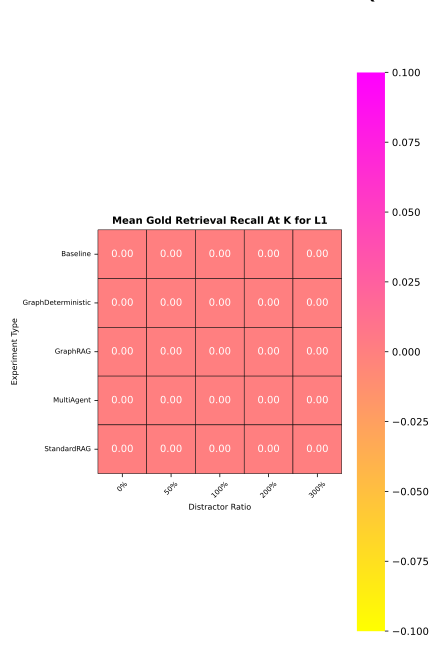


--- Generating Multi-Subplot Heatmap for Metric: correctness ---
   ✅ Saved multi-subplot heatmap for correctness to fig_heatmap_metric_comparison_correctness.svg


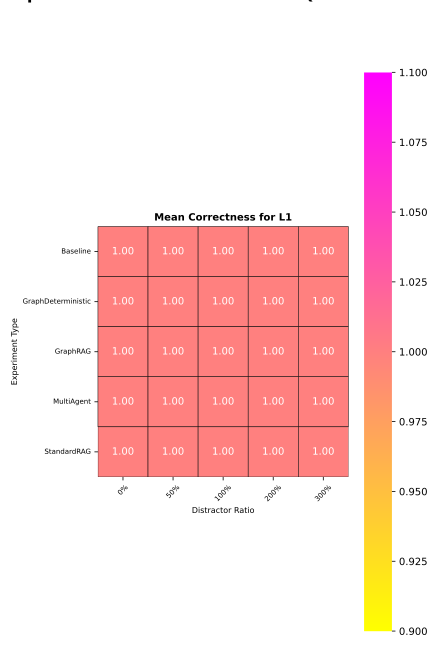


--- Generating Multi-Subplot Heatmap for Metric: relevance ---
   ✅ Saved multi-subplot heatmap for relevance to fig_heatmap_metric_comparison_relevance.svg


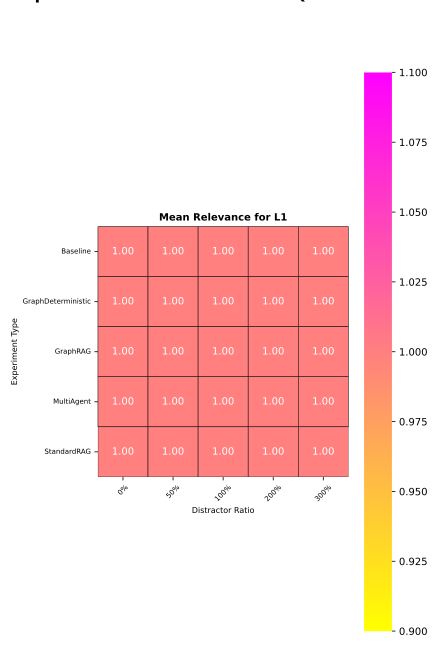


--- Generating Multi-Subplot Heatmap for Metric: groundedness ---
   ✅ Saved multi-subplot heatmap for groundedness to fig_heatmap_metric_comparison_groundedness.svg


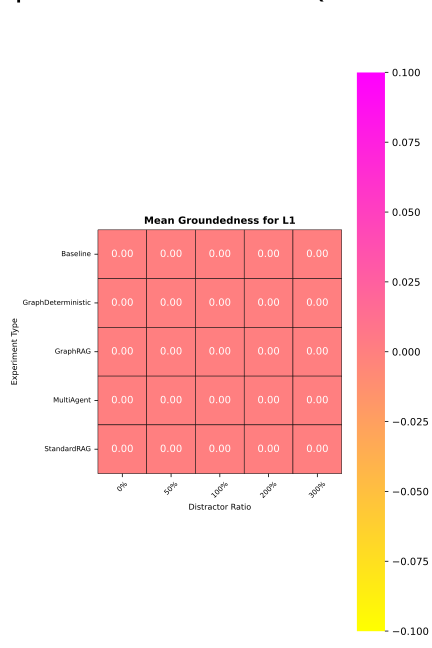


--- Generating Multi-Subplot Heatmap for Metric: rouge1_fmeasure ---
   ✅ Saved multi-subplot heatmap for rouge1_fmeasure to fig_heatmap_metric_comparison_rouge1_fmeasure.svg


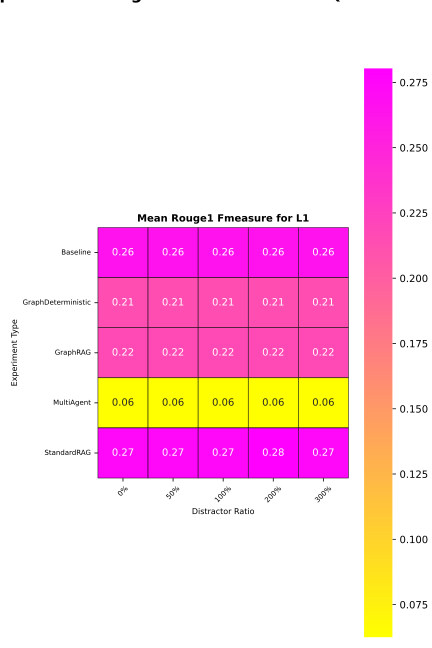


--- Generating Multi-Subplot Heatmap for Metric: rougeL_fmeasure ---
   ✅ Saved multi-subplot heatmap for rougeL_fmeasure to fig_heatmap_metric_comparison_rougel_fmeasure.svg


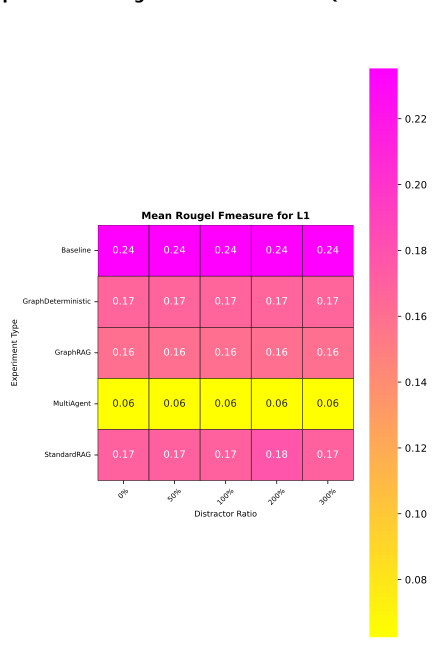

In [ ]:

# Extract all unique question IDs from qa_pairs and map them to their levels
question_id_to_level = {}

# Correctly get the qa_pairs list from the dm object
qa_pairs_list = dm.get_qa_pairs() # dm should be available from previous executions

for level_name, (start_idx, end_idx) in Config.QUESTION_LEVELS.items():
    for i in range(start_idx, end_idx): # Changed range to 0-30 for L1, 30-60 for L2 etc.
        # The original questions are QX.Y. The dataset now has QX.YvZ variations.
        # We need to map QX.YvZ to its original QX.Y identifier to correctly assign levels.
        # Assuming original_question_identifier is 'Q1.1' for 'Q1.1v0', 'Q1.1v1', 'Q1.1v2' etc.
        if i < len(qa_pairs_list):
            qa_item = qa_pairs_list[i]
            original_q_id_prefix = qa_item['original_question_identifier'] # e.g., 'Q1.1'
            question_id_to_level[qa_item['id']] = level_name

# Add a 'question_level' column to df_metrics for easier grouping
df_metrics['question_level'] = df_metrics['question_id'].map(question_id_to_level)

# --- End of Added Code ---

# List of metrics to plot
metrics_to_plot = [
    'gold_retrieval_recall_at_k',
    'correctness',
    'relevance',
    'groundedness',
    'rouge1_fmeasure',
    'rougeL_fmeasure'
]

# Determine unique question levels
unique_levels = sorted(df_metrics['question_level'].dropna().unique())
num_levels = len(unique_levels)

if num_levels == 0:
    print("No question levels found in df_metrics. Cannot generate multi-subplot heatmaps.")
else:
    for metric in metrics_to_plot:
        print(f"\n--- Generating Multi-Subplot Heatmap for Metric: {metric} ---")

        # Prepare metric data for global min/max calculation
        if isinstance(df_metrics['metrics'].iloc[0], str):
            df_metrics['metrics'] = df_metrics['metrics'].apply(ast.literal_eval)
        df_metrics[metric] = df_metrics['metrics'].apply(lambda x: x.get(metric, 0.0))

        # Calculate global vmin and vmax for the current metric across all data
        global_vmin = df_metrics[metric].min()
        global_vmax = df_metrics[metric].max()

        # Create a figure with subplots for each question level
        # Adjust figsize based on number of levels for better readability
        # Increased figure height and adjusted layout for better spacing
        fig, axes = plt.subplots(1, num_levels, figsize=(6 * num_levels, 9), sharey=True) # Increased figsize

        # Ensure axes is an array even if num_levels is 1
        if num_levels == 1:
            axes = [axes]

        for i, level_name in enumerate(unique_levels):
            df_level = df_metrics[df_metrics['question_level'] == level_name].copy()

            if df_level.empty:
                print(f"No data for level {level_name} for metric {metric}. Skipping subplot.")
                axes[i].set_visible(False) # Hide empty subplot
                continue

            # Call the updated plot_experiment_heatmap function for each subplot
            plot_experiment_heatmap(
                df_level,
                metric_name=metric,
                ax=axes[i],
                title_suffix=f"for {level_name}",
                vmin=global_vmin, # Pass global vmin
                vmax=global_vmax  # Pass global vmax
            )
            # Manually set ylabel only for the first subplot to avoid repetition
            if i > 0:
                axes[i].set_ylabel('') # Remove y-label for subsequent subplots

        fig.suptitle(f"Comparison of {metric.replace('_', ' ').title()} across Question Levels", fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjusted rect to give more space for the suptitle, allowing plots to fill more space

        # Save the combined figure as a SVG
        save_path = f"fig_heatmap_metric_comparison_{metric.replace('_', '_').lower()}.svg"
        plt.savefig(save_path, format='svg', dpi=300)
        print(f"   ✅ Saved multi-subplot heatmap for {metric} to {save_path}")
        plt.close(fig)
        display(SVG(save_path)) # Display the generated SVG in the notebook


# Statistical Analysis

The AdvancedMetrics class serves as the primary analytical engine for the research pipeline, providing a robust framework for statistical validation and comparative benchmarking.

Its architecture facilitates three core research functions:

Data Normalization and Ingestion: It implements a robust parsing routine to convert JSON-serialized evaluation metrics into a structured Pandas DataFrame, mapping raw outputs to a defined taxonomic schema (e.g., mapping 'correctness' to a 1-5 scale).

Statistical Inferencing: The class utilizes a bootstrapping algorithm to calculate 95% Confidence Intervals (CI) for all performance metrics. This ensures that the reported differences between architectures—such as Graph-Anchored versus Standard RAG—are statistically significant and not artifacts of sample variance.

Generative Fidelity Gap (GFG) Analysis: It calculates the 'GFG' by comparing observed performance against a theoretical performance ceiling. This allows us to quantify the precise 'accuracy loss' incurred by different retrieval models as they are subjected to increasing distractor noise.

Finally, the module automates the generation of a comprehensive results table and high-resolution visualizations, including bar charts and 'noise collapse' line plots, to document the systems' resilience across varying experimental conditions.


🔢 Calculating Statistics Table...

📊 FULL SCIENTIFIC RESULTS TABLE
| System              |   Distractor Ratio | Correctness (1-5) (95% CI)   | Relevance (1-5) (95% CI)   | Groundedness (0-1) (95% CI)   | Recall@K (95% CI)   | Precision@K (95% CI)   | MRR (95% CI)      | ROUGE-1 F1 (95% CI)   | ROUGE-L F1 (95% CI)   |
|:--------------------|-------------------:|:-----------------------------|:---------------------------|:------------------------------|:--------------------|:-----------------------|:------------------|:----------------------|:----------------------|
| Baseline            |                0   | 1.00 [1.00, 1.00]            | 1.00 [1.00, 1.00]          | 0.00 [0.00, 0.00]             | 0.00 [0.00, 0.00]   | 0.00 [0.00, 0.00]      | 0.00 [0.00, 0.00] | 0.26 [0.26, 0.26]     | 0.24 [0.24, 0.24]     |
| Baseline            |                0.5 | 1.00 [1.00, 1.00]            | 1.00 [1.00, 1.00]          | 0.00 [0.00, 0.00]             | 0.00 [0.00, 0.00]   | 0.00 [0.00, 0.00]

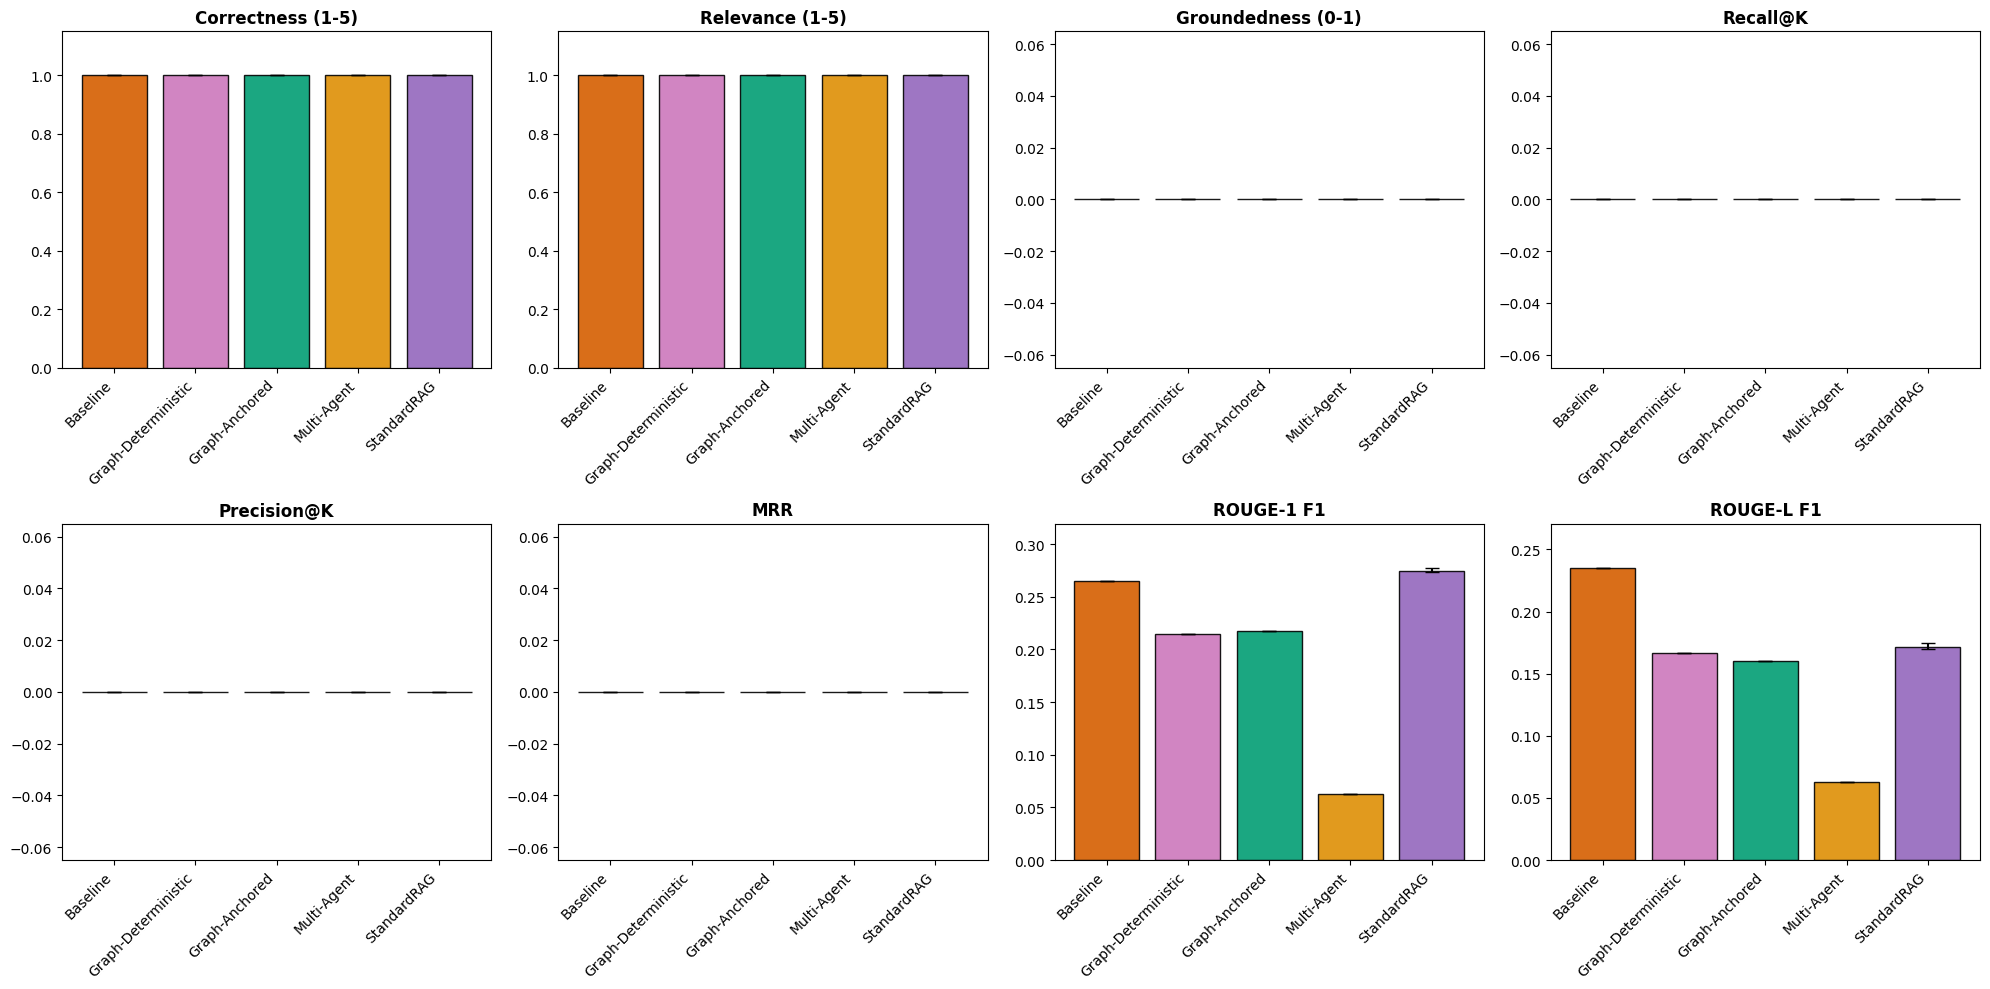

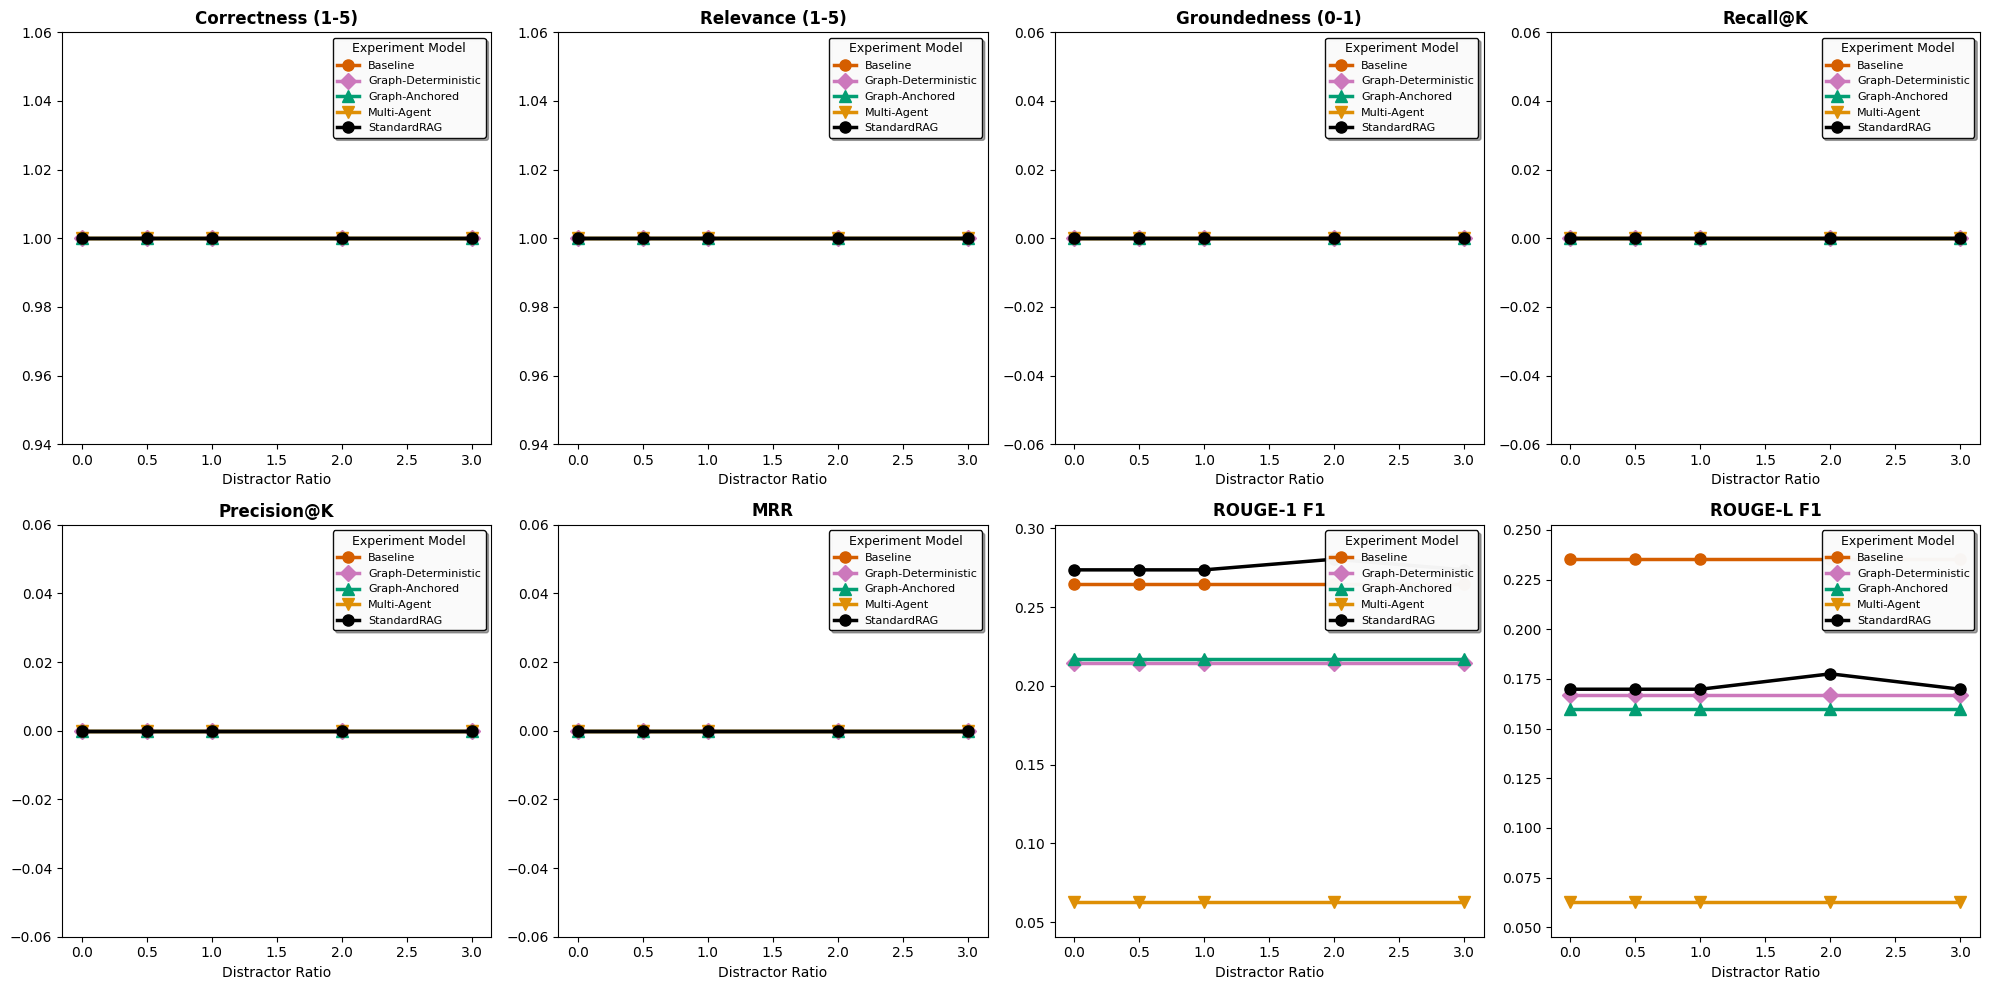

In [ ]:
class AdvancedMetrics:
    def __init__(self, results_path="experiment_results_groq.json", metrics_path="final_experiment_metrics.csv"):
        self.results = [] # Initialize as empty list
        if results_path: # Only attempt to load if results_path is provided
            try:
                with open(results_path, 'r') as f:
                    self.results = json.load(f)
            except FileNotFoundError:
                print(f"⚠️ Results JSON file not found at '{results_path}'. Proceeding with empty results data for raw outputs.")
            except Exception as e:
                print(f"⚠️ Error loading results JSON from '{results_path}': {e}. Proceeding with empty results data for raw outputs.")

        if not os.path.exists(metrics_path):
            raise FileNotFoundError(f"❌ Metrics CSV file not found: {metrics_path}. This file is crucial for analysis.")

        self.df = pd.read_csv(metrics_path)

        # Robust Parsing for metrics column if it's a string
        if 'metrics_dict' not in self.df.columns:
            self.df['metrics_dict'] = self.df['metrics'].apply(self._parse_metrics)

        self.metric_map = {
            'correctness': 'Correctness (1-5)',
            'relevance': 'Relevance (1-5)',
            'groundedness': 'Groundedness (0-1)',
            'gold_retrieval_recall_at_k': 'Recall@K',
            'gold_retrieval_precision_at_k': 'Precision@K',
            'gold_retrieval_mrr': 'MRR',
            'rouge1_fmeasure': 'ROUGE-1 F1',
            'rougeL_fmeasure': 'ROUGE-L F1'
        }

        self.available_metrics = []
        for key, label in self.metric_map.items():
            # Use metrics_dict to extract values, fallback to 0.0
            self.df[key] = self.df['metrics_dict'].apply(lambda x: float(x.get(key, 0.0)))
            if self.df[key].mean() > 0 or key in ['groundedness', 'gold_retrieval_recall_at_k', 'gold_retrieval_precision_at_k', 'gold_retrieval_mrr']:
                self.available_metrics.append(key)

        self.clean_names = lambda x: x.replace('GraphRAG', 'Graph-Anchored').replace('GraphDeterministic', 'Graph-Deterministic').replace('MultiAgent', 'Multi-Agent')

    def _parse_metrics(self, row):
        if isinstance(row, dict): return row
        try: return ast.literal_eval(row)
        except: return {}

    def get_bootstrap_ci(self, data, n_boot=1000, ci=0.95):
        """Calculates Mean and 95% Confidence Interval."""
        if len(data) < 2:
            m = np.mean(data) if len(data) > 0 else 0.0
            return m, m, m, 0.0, 0.0

        np.random.seed(42)
        boot_means = []
        for _ in range(n_boot):
            sample = np.random.choice(data, size=len(data), replace=True)
            boot_means.append(np.mean(sample))

        mean = np.mean(data)
        lower = np.percentile(boot_means, (1 - ci) / 2 * 100)
        upper = np.percentile(boot_means, (1 + ci) / 2 * 100)
        return mean, lower, upper, mean - lower, upper - mean

    # =========================================================
    # 1. CALCULATE GENERATIVE FIDELITY GAP (GFG)
    # =========================================================
    def calculate_generative_gap(self):
        """
        Calculates GFG with Statistical Significance (Mean ± Std).
        """
        print("\n🧪 CALCULATING GENERATIVE FIDELITY GAP (GFG)...")

        # 1. Group by Experiment Type (ignoring ratio for ceiling for now, as per standard GFG)
        stats = self.df.groupby('experiment_type')['correctness'].agg(['mean', 'std', 'count'])

        # Determine the 'ceiling' for GFG. This is typically the best performing model or an ideal score.
        # Using the max mean correctness across all experiment types for a more dynamic ceiling.
        ceiling = stats['mean'].max() if not stats.empty else 5.0
        if ceiling == 0: ceiling = 5.0 # Avoid division by zero if all means are zero

        gfg_data = []
        # Iterate over unique experiment types and distractor ratios to calculate GFG for each combo
        for (sys_type, ratio), group in self.df.groupby(['experiment_type', 'distractor_ratio']):
            model_mean = group['correctness'].mean()
            model_std = group['correctness'].std()
            model_count = group['correctness'].count()

            # GFG Formula: 1 - (observed / theoretical_max)
            gfg = 1 - (model_mean / ceiling)

            # Error Propagation for GFG (Standard Error of the Gap)
            # Simplified for direct observation, more complex for true error propagation of a ratio.
            # For simplicity, we can use the standard error of the mean for the observed score.
            if model_count > 1: # Avoid division by zero for std error
                gfg_error = (model_std / np.sqrt(model_count)) / ceiling # Approximating error on the ratio
            else:
                gfg_error = 0.0

            gfg_data.append({
                "Model": self.clean_names(sys_type),
                "Distractor Ratio": ratio,
                "Score (μ ± σ)": f"{model_mean:.2f} ± {model_std:.2f}",
                "Fidelity Gap": gfg, # Keep numeric for sorting
                "Gap Display": f"{gfg:.2%} (±{gfg_error:.2%})", # Academic Format
                "Interpretation": "Critical Loss" if gfg > 0.25 else "High Fidelity"
            })

        gfg_df = pd.DataFrame(gfg_data).sort_values(["Distractor Ratio", "Fidelity Gap"])

        # Print Clean Table
        print(gfg_df.drop(columns=["Fidelity Gap"]).to_markdown(index=False))
        gfg_df.to_csv("table3_generative_gap.csv", index=False)


    # =========================================================
    # 2. GENERATE FULL STAT TABLE
    # =========================================================
    def generate_stats_table(self):
        print("\n🔢 Calculating Statistics Table...")
        self.df['system_type'] = self.df['experiment_type'].apply(lambda x: x.split('_Ratio_')[0])
        summary_data = []

        grouped_df = self.df.groupby(['system_type', 'distractor_ratio'])

        for (sys_type, ratio), group in grouped_df:
            row = {'System': self.clean_names(sys_type), 'Distractor Ratio': ratio}
            for m in self.available_metrics:
                scores = group[m].values
                if len(scores) > 0:
                    mean, lower, upper, _, _ = self.get_bootstrap_ci(scores)
                    # Format: Mean [Lower, Upper]
                    row[f'{self.metric_map.get(m, m)} (95% CI)'] = f"{mean:.2f} [{lower:.2f}, {upper:.2f}]"
                else:
                    row[f'{self.metric_map.get(m, m)} (95% CI)'] = 'N/A'

            # Include error_category distribution if the column exists in the group
            if 'error_category' in group.columns:
                error_counts = group['error_category'].value_counts(normalize=True)
                for category, proportion in error_counts.items():
                    row[f'Error: {category}'] = f"{proportion:.2%}"
            summary_data.append(row)

        summary_df = pd.DataFrame(summary_data)

        # PRINT THE FULL TABLE
        print("\n" + "="*80)
        print("📊 FULL SCIENTIFIC RESULTS TABLE")
        print("="*80)
        print(summary_df.to_markdown(index=False))
        print("="*80 + "\n")

        summary_df.to_csv("final_results_with_ci.csv", index=False)
        print("✅ Saved table to 'final_results_with_ci.csv'")

    # =========================================================
    # 3. PLOT GRID (4 Columns)
    # =========================================================
    def generate_report(self):
        # First, generate and print the table
        self.generate_stats_table()

        # Then calculate GFG
        self.calculate_generative_gap()


        print("\n📈 Generating Plots...")
        self.df['system_type'] = self.df['experiment_type'].apply(lambda x: x.split('_Ratio_')[0])
        num_metrics = len(self.available_metrics)

        if num_metrics == 0:
            print("No metrics found.")
            return

        cols = 4
        rows = math.ceil(num_metrics / cols)

        # --- COLOR PALETTE (Colorblind Friendly) ---
        # As requested: "Previous style" using a distinct palette
        cp = sns.color_palette("colorblind")
        system_palette = {
            "Baseline": cp[3],              # Reddish
            "RAG": cp[0],                   # Blueish
            "Graph-Anchored": cp[2],        # Greenish
            "Graph-Deterministic": cp[4],   # Purpleish
            "Multi-Agent": cp[1]            # Orangeish
        }

        system_types = sorted(self.df['system_type'].unique())
        clean_systems = [self.clean_names(s) for s in system_types]

        # Map colors safely
        colors = [system_palette.get(s, sns.color_palette("tab10")[i % 10]) for i, s in enumerate(clean_systems)]
        markers = {'Baseline': 'o', 'RAG': 's', 'Graph-Anchored': '^', 'Graph-Deterministic': 'D', 'Multi-Agent': 'v'}

        # --- GENERATE BOTH PLOT TYPES ---
        for plot_type in ["bar", "line"]:
            # Setup Grid
            figsize = (cols * 5, rows * 5)
            fig, axes = plt.subplots(rows, cols, figsize=figsize, sharey=False)
            axes_flat = axes.flatten() if num_metrics > 1 else [axes]

            for i in range(len(axes_flat)):
                ax = axes_flat[i]
                if i < num_metrics:
                    metric = self.available_metrics[i]

                    if plot_type == "bar":
                        # --- BAR CHART ---
                        plot_data = []
                        for sys in system_types:
                            # For bar chart, aggregate across all ratios
                            d = self.df[self.df['system_type'] == sys][metric].values
                            if len(d) > 0:
                                mean, lower, upper, err_l, err_u = self.get_bootstrap_ci(d)
                                plot_data.append({'System': self.clean_names(sys), 'Mean': mean, 'Error': [err_l, err_u]})

                        p_df = pd.DataFrame(plot_data)
                        if not p_df.empty:
                            p_df['System'] = pd.Categorical(p_df['System'], categories=clean_systems, ordered=True)
                            p_df = p_df.sort_values('System')

                            x_pos = np.arange(len(p_df))
                            yerr = np.array(p_df['Error'].tolist()).T

                            ax.bar(x_pos, p_df['Mean'], yerr=yerr, capsize=5, color=colors, edgecolor='black', alpha=0.9)
                            ax.set_xticks(x_pos)
                            ax.set_xticklabels(p_df['System'], rotation=45, ha='right', fontsize=10)
                            ax.set_title(self.metric_map.get(metric, metric), fontweight='bold')
                            ax.autoscale(axis='y', tight=False)
                            ax.margins(y=0.15)

                    elif plot_type == "line":
                        # --- NOISE COLLAPSE LINE CHART ---
                        line_data = []
                        for sys in system_types:
                            for ratio in sorted(self.df['distractor_ratio'].unique()):
                                subset = self.df[(self.df['system_type'] == sys) & (self.df['distractor_ratio'] == ratio)]
                                vals = subset[metric].values
                                if len(vals) > 0:
                                    m, l, u, _, _ = self.get_bootstrap_ci(vals)
                                    line_data.append({'System': self.clean_names(sys), 'Ratio': ratio, 'Mean': m, 'Lower': l, 'Upper': u})

                        l_df = pd.DataFrame(line_data)
                        if not l_df.empty:
                            for clean_sys in clean_systems:
                                sub = l_df[l_df['System'] == clean_sys].sort_values('Ratio')
                                if not sub.empty:
                                    col = system_palette.get(clean_sys, 'black')
                                    ax.plot(sub['Ratio'], sub['Mean'], marker=markers.get(clean_sys, 'o'),
                                            label=clean_sys, color=col, linewidth=2.5, markersize=8)
                                    ax.fill_between(sub['Ratio'], sub['Lower'], sub['Upper'], color=col, alpha=0.15)

                            ax.set_title(self.metric_map.get(metric, metric), fontweight='bold')
                            ax.set_xlabel("Distractor Ratio")
                            ax.autoscale(axis='y', tight=False)
                            ax.margins(y=0.1)
                            # Box on top right
                            ax.legend(title="Experiment Model", loc='upper right', fontsize=8, title_fontsize=9, framealpha=0.95, edgecolor='black', shadow=True)

                else:
                    ax.set_visible(False) # Hide empty grid slots

            plt.tight_layout()
            filename = f"metrics_{plot_type}_grid.pdf"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✅ Saved plot to '{filename}'")


if __name__ == "__main__":
    # Ensure the path points to your CSV file
    metrics = AdvancedMetrics(metrics_path="final_experiment_metrics.csv", results_path="debug_results_raw.json")
    metrics.generate_report()

## Generative fidelity gap

This cell implements the Generative Fidelity Gap (GFG) visualization, a high-fidelity diagnostic tool used to measure the 'robustness loss' of your RAG architectures.

Technically, the script performs three core operations:

Ceiling Calculation: It identifies the highest mean correctness score across all experiments to establish a theoretical performance 'ceiling'.
Gap Derivation: It calculates the GFG for each model-noise combination using the formula 1 - (observed / ceiling). This represents the percentage of accuracy lost relative to the best possible system performance.

Heatmap Rendering: It generates a publication-quality heatmap using the magma_r color palette. The visualization is specifically configured with high-resolution settings (400 DPI) and a fixed-width display to ensure clarity.

This specific plot is crucial for your research because it visually isolates the 'Breaking Point'—the specific distractor ratio where a model's fidelity collapses compared to its baseline.

###  Fidelity Gap Heatmap

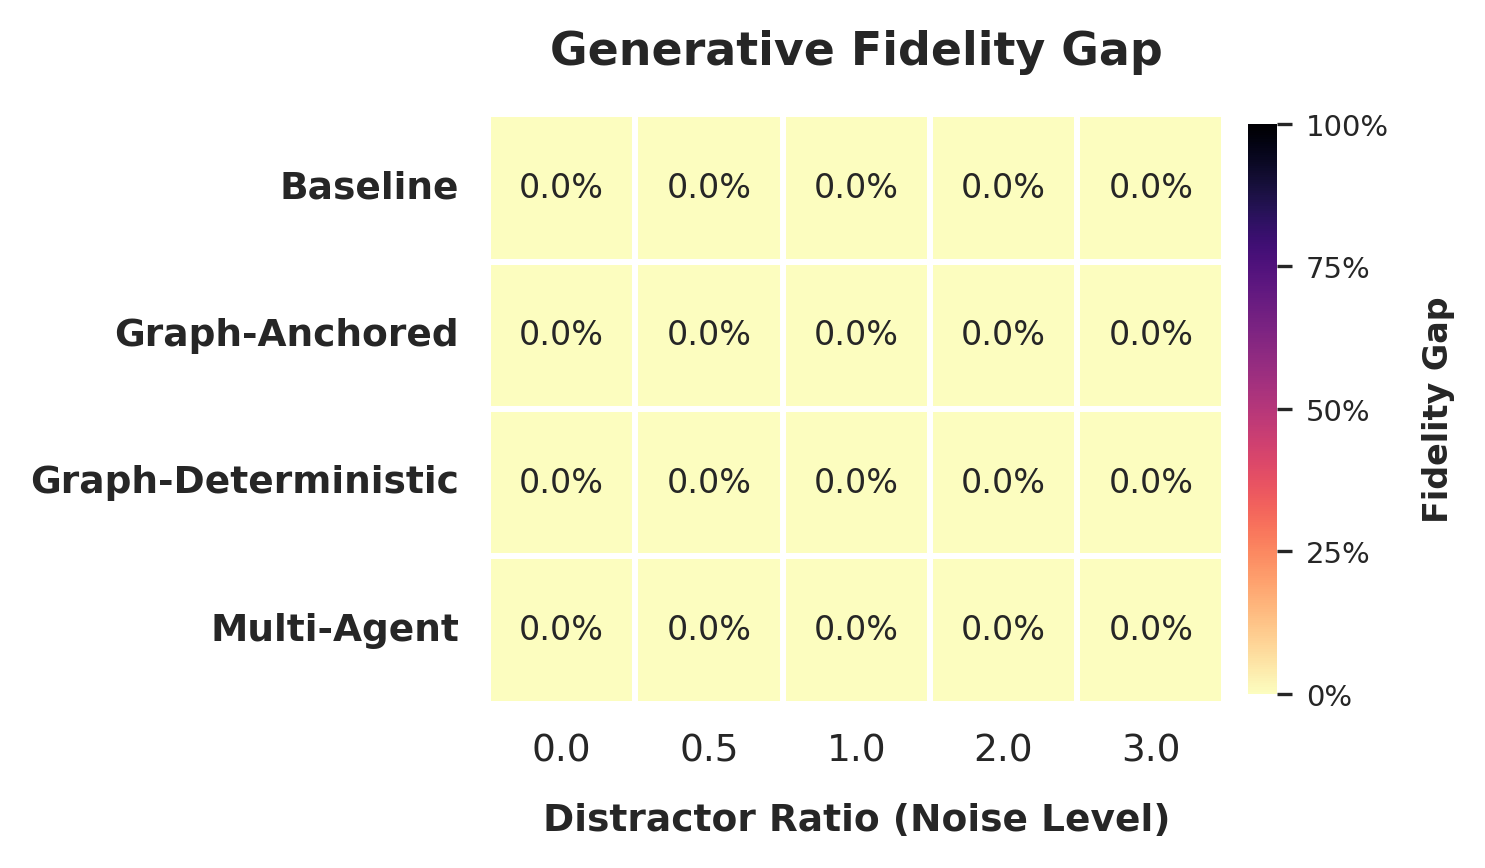

In [ ]:

# 1. Load Data
if 'df' not in locals():
    df = pd.read_csv('final_experiment_metrics.csv')

# Parse metrics
def get_correctness(metrics_str):
    try:
        if pd.isna(metrics_str): return 0
        d = ast.literal_eval(metrics_str)
        return d.get('correctness', 0)
    except:
        return 0

df['correctness'] = df['metrics'].apply(get_correctness)

# Calculate Ceiling
stats = df.groupby('experiment_type')['correctness'].agg(['mean'])
ceiling = stats['mean'].max() if not stats.empty else 5.0
if ceiling == 0: ceiling = 5.0

# Calculate Gap
gfg_data = []
def clean_names(x):
    return x.replace('GraphRAG', 'Graph-Anchored').replace('GraphDeterministic', 'Graph-Deterministic').replace('MultiAgent', 'Multi-Agent').split('_Ratio_')[0]

df['system_type'] = df['experiment_type'].apply(clean_names)

for (sys_type, ratio), group in df.groupby(['system_type', 'distractor_ratio']):
    model_mean = group['correctness'].mean()
    gfg = 1 - (model_mean / ceiling)
    gfg_data.append({"Model": sys_type, "Distractor Ratio": ratio, "Fidelity Gap": gfg})

df_gap = pd.DataFrame(gfg_data)
heatmap_data = df_gap.pivot(index="Model", columns="Distractor Ratio", values="Fidelity Gap")

# Sort
desired_order = ["Baseline", "RAG", "Graph-Anchored", "Graph-Deterministic", "Multi-Agent"]
existing_order = [m for m in desired_order if m in heatmap_data.index]
if existing_order:
     heatmap_data = heatmap_data.reindex(existing_order)

# 2. PLOTTING (Fixed Size Logic)
# ---------------------------------------------------------
# Set font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Fixed Figure Size (Inches) -> (Width, Height)
# 5x4 inches is standard for single-column paper figures
fig = plt.figure(figsize=(5, 4), dpi=400)

with sns.axes_style("white"):
    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1%",
        cmap="magma_r",      # High contrast: Black=Good, Yellow=Bad
        vmin=0, vmax=1,
        square=True,
        linewidths=1.0,
        linecolor='white',
        cbar=True,
        cbar_kws={
            "label": "Fidelity Gap (Lower is Better)",
            "shrink": 0.6,
            "fraction": 0.04,
            "pad": 0.03,
            "ticks": [0, 0.25, 0.5, 0.75, 1.0]
        },
        annot_kws={"size": 8, "weight": "normal"}
    )

# Axis & Labels
plt.ylabel('', fontsize=0)
plt.yticks(fontsize=9, weight='bold', rotation=0)
plt.xlabel('Distractor Ratio (Noise Level)', fontsize=9, weight='bold', labelpad=8)
plt.xticks(fontsize=9, rotation=0)
plt.title('Generative Fidelity Gap', fontsize=11, weight='bold', pad=12)

# Fix Colorbar labels
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=7)
cbar.ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
cbar.set_label("Fidelity Gap", fontsize=8, weight='bold', labelpad=8)

plt.tight_layout()

# SAVE FIRST (High Res)
plt.savefig('fidelity_gap_heatmap_crisp.png', dpi=300, bbox_inches='tight')
plt.savefig('fidelity_gap_heatmap_crisp.svg', format='svg', bbox_inches='tight')

# CLOSE PLOT (Prevents automatic huge display)
plt.close()

# 3. DISPLAY WITH FIXED WIDTH (The Fix)
# ---------------------------------------------------------
display(Markdown("###  Fidelity Gap Heatmap"))
# width=600 forces the browser to render it at 600px, regardless of the 300 DPI
display(Image(filename='fidelity_gap_heatmap_crisp.png', width=600))

## Trace Visualizer

In [ ]:


class TraceVisualizer:
    def __init__(self, results_path="debug_results_raw.json", metrics_path="final_experiment_metrics.csv"):
        if not os.path.exists(results_path) or not os.path.exists(metrics_path):
            print(f"⚠️ Warning: Files not found. Ensure {results_path} and {metrics_path} exist.")
            self.results = []
            self.metrics = pd.DataFrame()
        else:
            self.results = json.load(open(results_path))
            self.metrics = pd.read_csv(metrics_path)

    def _get_answer_string(self, answer_obj: Union[str, Dict[str, Any], List[Any], Tuple[Any, ...]]) -> str:
        if isinstance(answer_obj, dict):
            # Try to get a 'final_answer' key if it's a dict (common for multi_hop, multi_agent JSON outputs)
            answer_text = answer_obj.get('final_answer', None)
            if answer_text is None:
                # If 'final_answer' not found, or is None, try 'answer' or just stringify the whole dict
                answer_text = answer_obj.get('answer', str(answer_obj))
            if answer_text == "null": # Handle explicit 'null' string from LLM
                answer_text = ""
        elif isinstance(answer_obj, list): # Explicitly handle list by joining elements
            answer_text = " ".join([str(item) for item in answer_obj if item is not None])
        elif isinstance(answer_obj, tuple): # Explicitly handle tuple by taking the first element
            answer_text = str(answer_obj[0]) if answer_obj and answer_obj[0] is not None else ""
        else:
            answer_text = str(answer_obj if answer_obj is not None else "") # Ensure it's a string, handle None

        return answer_text

    def generate_trace_report(self, question_id):
        entry = None
        for exp_type in ['MultiAgent', 'GraphRAG', 'GraphDeterministic']:
            for r in self.results:
                if r.get('question_id') == question_id and exp_type in r.get('experiment_type', ''):
                    entry = r
                    break
            if entry: break

        if not entry:
            return None, f"Entry for {question_id} not found"

        # Get Context
        context_text = ""
        if 'MultiAgent' in entry.get('experiment_type', ''):
            if entry.get('retrieved_text_chunks'):
                context_text = "\n\n".join(entry['retrieved_text_chunks'])
        else:
            context_text = entry.get('context_used', "")

        # --- PARSING ---
        generated_answer = self._get_answer_string(entry.get('generated_answer', ''))
        accepted_ids = set()

        lines = generated_answer.split('\n')
        id_pattern = re.compile(r"ID:\s*(.*?)(?=\])") # Modified regex to handle missing closing bracket if present.

        for line in lines:
            match = id_pattern.search(line)
            if match:
                node_id = match.group(1).strip()
                accepted_ids.add(node_id)

        if accepted_ids:
            sorted_nodes = sorted(list(accepted_ids))
            trace_text = f"<b>Path:</b> {' &rarr; '.join(sorted_nodes)}"
        else:
            trace_text = "<b>Path:</b> No accepted nodes parsed from answer." # Changed message

        svg_output = self._render_topological_map(context_text, question_id, accepted_ids)
        return svg_output, trace_text

    def _render_topological_map(self, context_text, qid, accepted_node_ids):
        G = nx.DiGraph()

        # Root Node
        G.add_node("ROOT", type='root', color='#E74C3C', label="Query\nContext")

        candidate_pattern = re.compile(
            r"CANDIDATE \d+ \[ID: (.*?)\]\n\s+- TYPE: (.*?)\n\s+- CONNECTS TO: (.*?)(?:\n|$)"
        )

        candidates_found = 0
        for match in candidate_pattern.finditer(context_text):
            if candidates_found >= 15: break

            hub_id = match.group(1).strip()
            node_type = match.group(2).strip()
            conns_str = match.group(3).strip()

            # Case-insensitive check
            is_accepted = False
            for acc_id in accepted_node_ids:
                if hub_id.lower() == acc_id.lower():
                    is_accepted = True
                    break

            color = '#F1C40F' if is_accepted else '#3498DB'

            # Wrap text slightly wider (15 chars) to make labels less "tall"
            label = textwrap.fill(hub_id, 15)
            G.add_node(hub_id, type=node_type, color=color, label=label)
            G.add_edge("ROOT", hub_id)

            if conns_str:
                conns = [c.strip() for c in conns_str.split(',') if c.strip()]
                for conn in conns:
                    if not G.has_node(conn):
                        G.add_node(conn, color='#2ECC71', label=textwrap.fill(conn, 15))
                    G.add_edge(hub_id, conn)

            candidates_found += 1

        if G.number_of_nodes() <= 1:
            return None

        # --- PLOTTING ---
        plt.figure(figsize=(6, 5))

        # KEY FIX: Increase 'k' to spread nodes out, increase iterations
        pos = nx.spring_layout(G, k=3.5, iterations=300, seed=42)

        node_colors = [G.nodes[n].get('color', '#95A5A6') for n in G.nodes]
        labels = {n: G.nodes[n].get('label', n) for n in G.nodes}

        # KEY FIX: Smaller node_size
        nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, edgecolors='#333333', linewidths=0.5)

        def check_accepted(name):
            return any(name.lower() == acc.lower() for acc in accepted_node_ids)

        edge_colors = []
        widths = []
        for u, v in G.edges():
            is_gold = False
            u_acc = check_accepted(u)
            v_acc = check_accepted(v)

            if u == "ROOT" and v_acc: is_gold = True
            elif u_acc: is_gold = True
            if u_acc and v_acc: is_gold = True

            if is_gold:
                edge_colors.append('#F1C40F')
                widths.append(2.0) # Slightly thinner highlight for cleaner look
            else:
                edge_colors.append('#BDC3C7')
                widths.append(0.5)

        nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=widths, arrowsize=10)

        # KEY FIX: Smaller font_size
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=6, font_family='sans-serif', font_weight='bold')

        plt.title(f"QID: {qid}", fontsize=9, fontweight='bold')
        plt.axis('off')

        filename = f"temp_{qid}.svg"
        plt.savefig(filename, format='svg', bbox_inches='tight')
        plt.close()

        with open(filename, 'r') as f:
            svg_content = f.read()
        if os.path.exists(filename): os.remove(filename)

        return svg_content

# --- MAIN ---
if __name__ == "__main__":
    # Add checks for file existence before instantiation
    print(f"Checking for debug_results_raw.json: {os.path.exists('debug_results_raw.json')}")
    print(f"Checking for final_experiment_metrics.csv: {os.path.exists('final_experiment_metrics.csv')}")
    viz = TraceVisualizer("debug_results_raw.json", "final_experiment_metrics.csv")

    forced_ids = ['Q1.1', 'Q2.1', 'Q3.1', 'Q4.1']
    print(f"Generating for: {forced_ids}")

    visuals = []

    for qid in forced_ids:
        svg_data, trace_note = viz.generate_trace_report(qid)
        if svg_data:
            html_card = f"""
            <div style="border: 1px solid #ddd; padding: 10px; border-radius: 8px; background: #fff; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
                <h4 style="margin: 0 0 5px 0;">{qid}</h4>
                <div style="font-size: 11px; color: #444; margin-bottom: 10px; font-family: monospace;">{trace_note}</div>
                <div>{svg_data}</div>
            </div>
            """
            visuals.append(html_card)
        else:
            visuals.append(f"<div style='padding:10px;'>{qid}: No data or graph could be generated.</div>") # Changed message

    if visuals:
        grid_html = """<div style=\"display: grid; grid-template-columns: 1fr 1fr; gap: 15px;\">"""
        grid_html += "".join(visuals)
        grid_html += "</div>"
        display(HTML(grid_html))


Checking for debug_results_raw.json: True
Checking for final_experiment_metrics.csv: True
Generating for: ['Q1.1', 'Q2.1', 'Q3.1', 'Q4.1']


## 6. EXECUTIVE SUMMARY VISUALIZATIONS
This section adds high-level comparative visualizations to analyze the trade-offs between different RAG architectures.

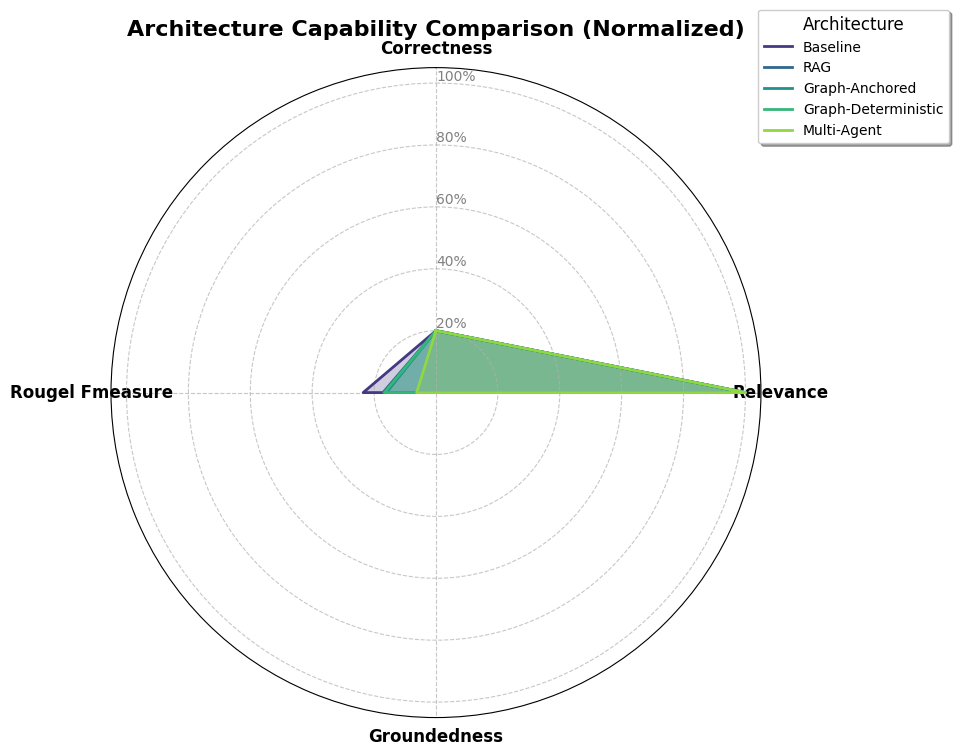

In [ ]:
def plot_radar_comparison(df_metrics):
    # Aggregate metrics by experiment type
    categories = ['correctness', 'relevance', 'groundedness', 'rougeL_fmeasure']
    # Normalize correctness to 0-1 scale for the radar chart
    df_plot = df_metrics.copy()
    df_plot['correctness'] = df_plot['correctness'] / 5.0 # Assuming max correctness is 5

    # Map system types to clean names for consistency with other plots
    clean_names_map = {
        'Baseline': 'Baseline',
        'StandardRAG': 'RAG',
        'GraphRAG': 'Graph-Anchored',
        'GraphDeterministic': 'Graph-Deterministic',
        'MultiAgent': 'Multi-Agent'
    }
    df_plot['system_type_clean'] = df_plot['system_type'].map(clean_names_map)
    summary = df_plot.groupby('system_type_clean')[categories].mean().reset_index()

    # Ensure all systems are present in the summary, fill with 0 if not
    all_systems = list(clean_names_map.values())
    summary = summary.set_index('system_type_clean').reindex(all_systems, fill_value=0).reset_index()

    # Number of variables we're plotting. +1 for closing the loop
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # The plot is circular, so we need to "close the loop" by repeating the first value.
    # Also, repeat the first angle to close the polygon in the plot.
    angles += angles[:1]

    # Create the figure and subplot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Color palette (using a more vibrant one)
    palette = sns.color_palette('viridis', len(summary['system_type_clean'].unique()))

    for i, row in summary.iterrows():
        values = row[categories].tolist()
        values += values[:1] # Close the loop
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['system_type_clean'], color=palette[i])
        ax.fill(angles, values, color=palette[i], alpha=0.25)

    # Set theta and labels
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1) # Clockwise direction

    # Draw x-axis labels at the correct angle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_', ' ').title() for c in categories], fontsize=12, fontweight='bold')

    # Draw y-axis labels
    ax.set_rlabel_position(0) # Move radial labels away from plotted line
    yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{y:.0%}' for y in yticks], color='gray', size=10)
    ax.tick_params(axis='y', colors='gray') # Make y-tick labels gray

    # Grid and Title
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_title('Architecture Capability Comparison (Normalized)', va='bottom', fontsize=16, fontweight='bold', pad=20)

    # Legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10, title='Architecture', title_fontsize=12, frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

if 'df_metrics' in locals() or os.path.exists('final_experiment_metrics.csv'):
    data = df_metrics if 'df_metrics' in locals() else pd.read_csv('final_experiment_metrics.csv')
    # Basic cleaning if needed
    if 'system_type' not in data.columns:
        data['system_type'] = data['experiment_type'].apply(lambda x: x.split('_Ratio_')[0] if '_Ratio_' in x else x)
    plot_radar_comparison(data)


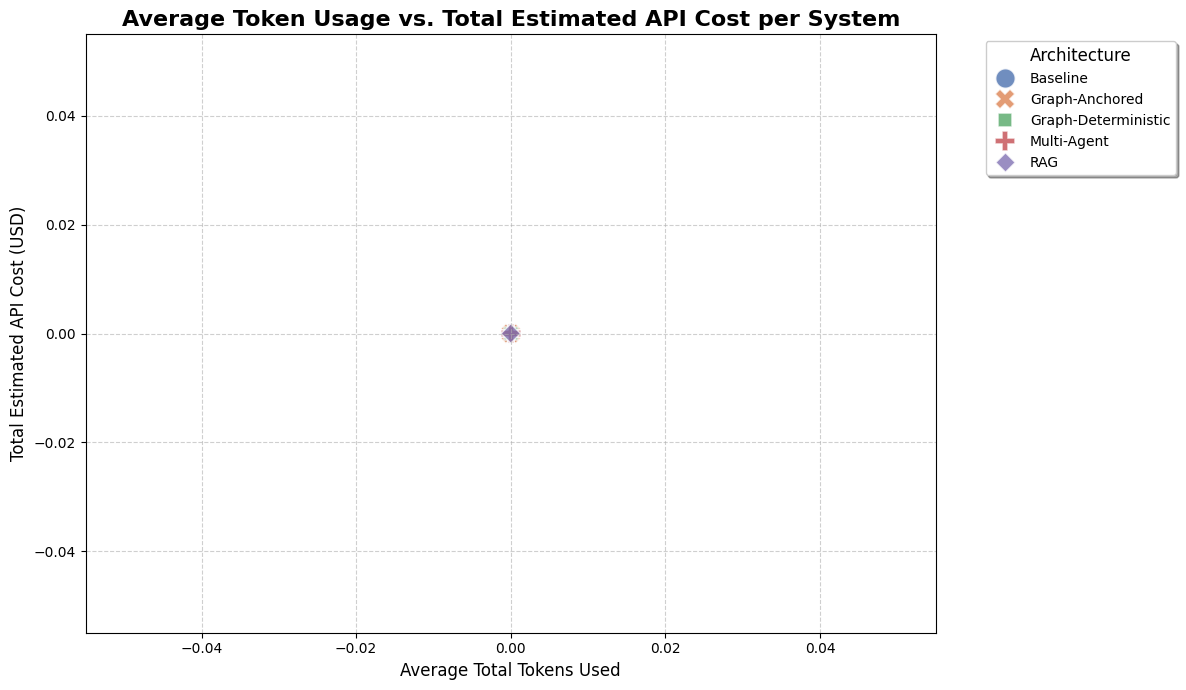

In [ ]:
def plot_cost_efficiency(results_json_path):
    if not os.path.exists(results_json_path):
        print('Results file not found for cost analysis.')
        return

    with open(results_json_path, 'r') as f:
        results = json.load(f)

    data = []
    for r in results:
        system_name = r.get('experiment_type', 'Unknown').split('_Ratio_')[0] if '_Ratio_' in r.get('experiment_type', 'Unknown') else r.get('experiment_type', 'Unknown')
        clean_system_name = system_name.replace('GraphRAG', 'Graph-Anchored').replace('GraphDeterministic', 'Graph-Deterministic').replace('MultiAgent', 'Multi-Agent').replace('StandardRAG', 'RAG')

        data.append({
            'System': clean_system_name,
            'Tokens': r.get('total_tokens', 0),
            'Input Tokens': r.get('input_tokens', 0),
            'Output Tokens': r.get('output_tokens', 0),
            'Cost': r.get('estimated_cost', 0),
            'Question ID': r.get('question_id', 'N/A')
        })

    cost_df = pd.DataFrame(data)

    # Aggregate cost and tokens per system for a clearer scatter plot if multiple runs per system
    # For debug matrix, this will likely still be one point per system
    aggregated_cost_df = cost_df.groupby('System').agg(
        Avg_Tokens=('Tokens', 'mean'),
        Total_Cost=('Cost', 'sum') # Summing cost if multiple Qs per system or taking mean if one Q
    ).reset_index()


    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=aggregated_cost_df,
        x='Avg_Tokens',
        y='Total_Cost',
        hue='System',
        style='System',
        s=200, # Increase marker size
        alpha=0.8, # Slightly transparent
        palette='deep'
    )

    plt.title('Average Token Usage vs. Total Estimated API Cost per System', fontsize=16, fontweight='bold')
    plt.xlabel('Average Total Tokens Used', fontsize=12)
    plt.ylabel('Total Estimated API Cost (USD)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12, frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

plot_cost_efficiency('debug_results_raw.json')


## 7. ERROR TAXONOMY & NOISE SENSITIVITY
This section analyzes specific failure modes and the 'Breaking Point' of each retrieval architecture under increasing noise levels.

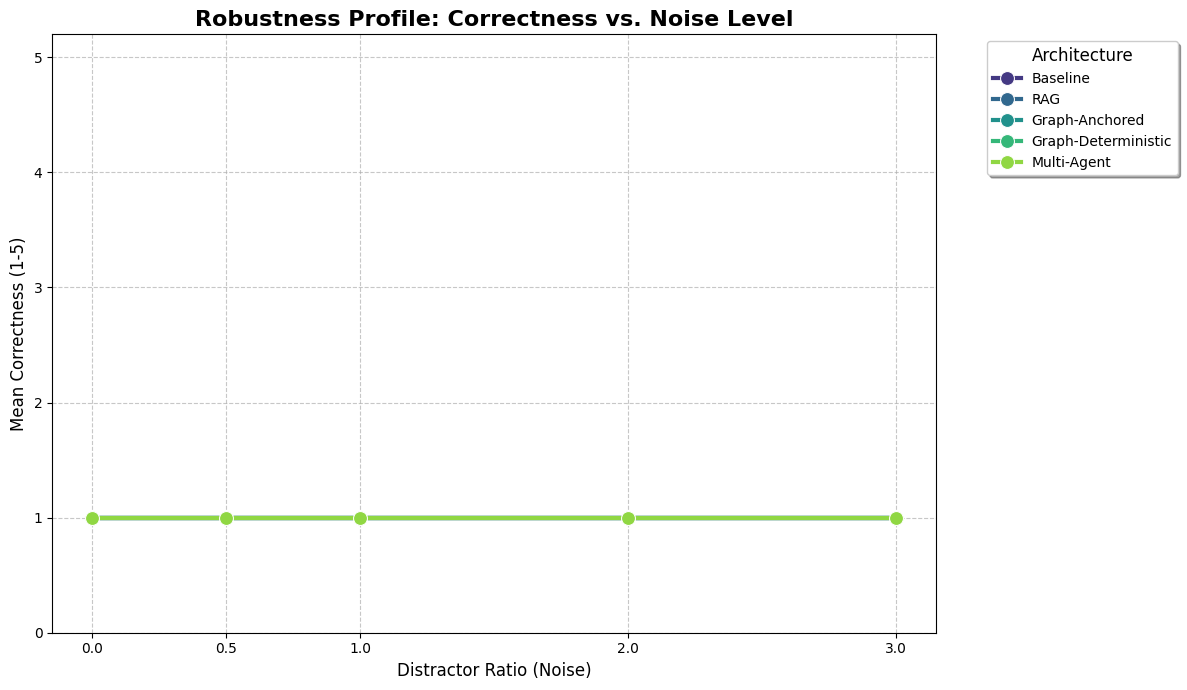

In [ ]:
def plot_noise_sensitivity(df_metrics):
    """Plots how Correctness decays as Distractor Ratio increases."""
    plt.figure(figsize=(12, 7))
    # Ensure system_type exists and is cleaned
    if 'system_type' not in df_metrics.columns:
        df_metrics['system_type'] = df_metrics['experiment_type'].apply(lambda x: x.split('_Ratio_')[0] if '_Ratio_' in x else x)

    clean_names_map = {
        'Baseline': 'Baseline',
        'StandardRAG': 'RAG',
        'GraphRAG': 'Graph-Anchored',
        'GraphDeterministic': 'Graph-Deterministic',
        'MultiAgent': 'Multi-Agent'
    }
    df_metrics['system_type_clean'] = df_metrics['system_type'].map(clean_names_map)

    sns.lineplot(
        data=df_metrics,
        x='distractor_ratio',
        y='correctness',
        hue='system_type_clean',
        marker='o',
        linewidth=3, # Thicker lines
        markersize=10, # Larger markers
        palette='viridis' # More vibrant palette
    )

    plt.title('Robustness Profile: Correctness vs. Noise Level', fontsize=16, fontweight='bold')
    plt.xlabel('Distractor Ratio (Noise)', fontsize=12)
    plt.ylabel('Mean Correctness (1-5)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0, 5.2) # Set y-axis limit for clarity, assuming correctness is 1-5
    plt.xticks(sorted(df_metrics['distractor_ratio'].unique())) # Ensure all ratios are shown as ticks
    plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12, frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

if 'df_metrics' in locals():
    plot_noise_sensitivity(df_metrics)


<Figure size 1200x700 with 0 Axes>

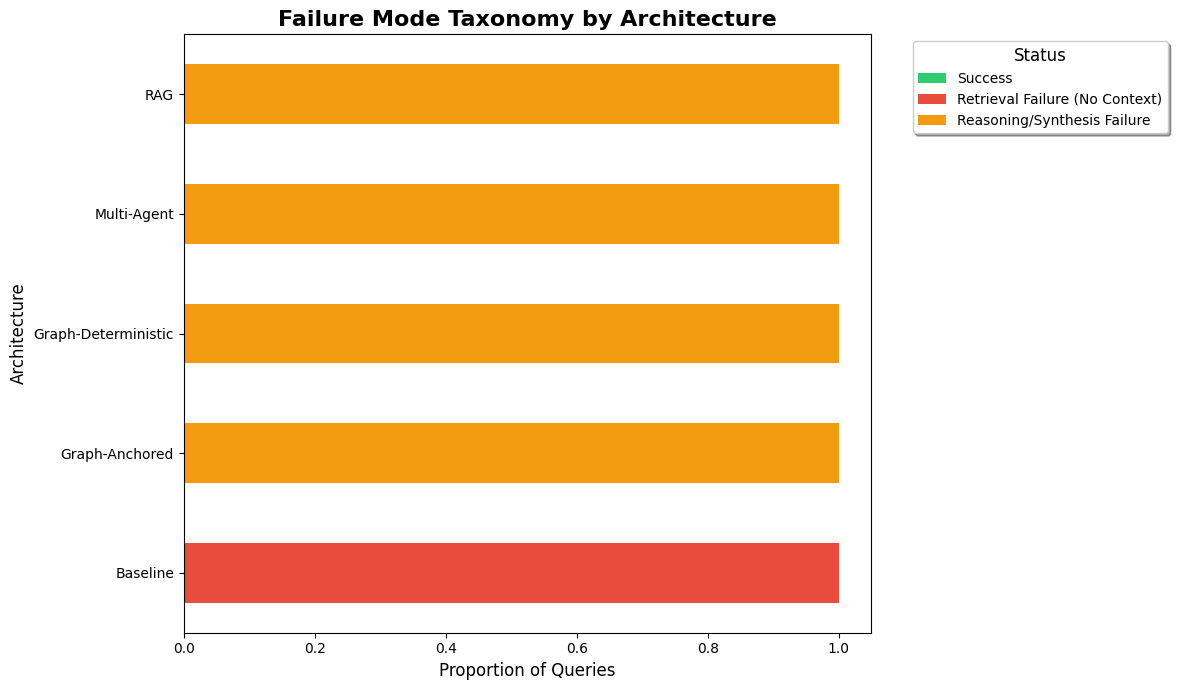

In [ ]:
def plot_failure_modes(df_metrics):
    """
    Categorizes failures by checking if retrieved_text_chunks were empty
    vs if the answer was still incorrect.
    """
    # Create a simple heuristic for failure mode
    def categorize(row):
        # Assuming correctness scale is 1-5, 4.0 or above is a good threshold for 'Success'
        if row['metrics_dict'].get('correctness', 0.0) >= 4.0:
            return 'Success'

        # Check if context was retrieved at all
        # Context could be an empty list, a string '[]', or actual content
        retrieved_chunks = row.get('retrieved_text_chunks', '[]')
        if not retrieved_chunks or retrieved_chunks == '[]' or (isinstance(retrieved_chunks, list) and len(retrieved_chunks) == 0):
            return 'Retrieval Failure (No Context)'

        # If context was there but answer was incorrect
        return 'Reasoning/Synthesis Failure'

    df_plot = df_metrics.copy()

    # Ensure 'metrics_dict' column exists by parsing the 'metrics' string column
    def _local_parse_metrics(row_val):
        if isinstance(row_val, dict): return row_val
        try: return ast.literal_eval(row_val)
        except: return {}

    if 'metrics' in df_plot.columns:
        df_plot['metrics_dict'] = df_plot['metrics'].apply(_local_parse_metrics)
    else:
        # Fallback if 'metrics' column is missing
        df_plot['metrics_dict'] = [{}] * len(df_plot) # Default to empty dicts

    # Ensure 'system_type' is clean and consistent
    if 'system_type' not in df_plot.columns:
        df_plot['system_type'] = df_plot['experiment_type'].apply(lambda x: x.split('_Ratio_')[0] if '_Ratio_' in x else x)
    clean_names_map = {
        'Baseline': 'Baseline',
        'StandardRAG': 'RAG',
        'GraphRAG': 'Graph-Anchored',
        'GraphDeterministic': 'Graph-Deterministic',
        'MultiAgent': 'Multi-Agent'
    }
    df_plot['system_type_clean'] = df_plot['system_type'].map(clean_names_map)

    # Apply categorization
    df_plot['Failure_Mode'] = df_plot.apply(categorize, axis=1)

    # Calculate cross-tabulation for proportions
    ct = pd.crosstab(df_plot['system_type_clean'], df_plot['Failure_Mode'], normalize='index')

    # Ensure all three categories exist, even if 0, for consistent plotting
    all_modes = ['Success', 'Retrieval Failure (No Context)', 'Reasoning/Synthesis Failure']
    for mode in all_modes:
        if mode not in ct.columns:
            ct[mode] = 0.0
    ct = ct[all_modes] # Reorder columns consistently

    plt.figure(figsize=(12, 7)) # Larger figure size
    ax = ct.plot(kind='barh', stacked=True, figsize=(12, 7),
                  color={'Success': '#2ecc71', 'Retrieval Failure (No Context)': '#e74c3c', 'Reasoning/Synthesis Failure': '#f39c12'})

    plt.title('Failure Mode Taxonomy by Architecture', fontsize=16, fontweight='bold')
    plt.xlabel('Proportion of Queries', fontsize=12)
    plt.ylabel('Architecture', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12, frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

if 'df_metrics' in locals():
    plot_failure_modes(df_metrics)


## 8. STATISTICAL SIGNIFICANCE (P-VALUES)
This analysis determines if the performance differences between architectures are statistically significant using a T-test matrix.

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


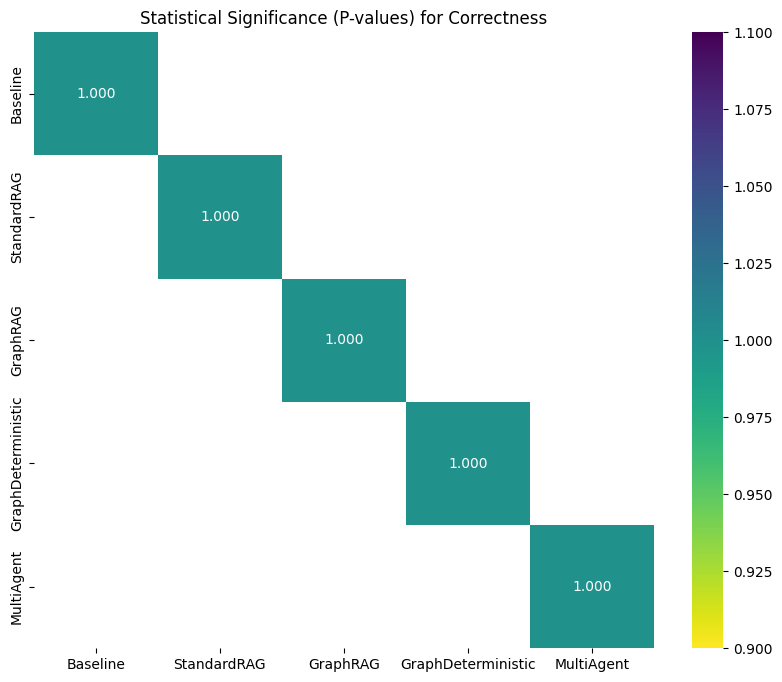

Note: P-values < 0.05 typically indicate statistical significance.


In [ ]:
import scipy.stats as stats

def plot_significance_matrix(df_metrics, metric='correctness'):
    systems = df_metrics['system_type'].unique()
    p_matrix = pd.DataFrame(index=systems, columns=systems)

    for s1 in systems:
        for s2 in systems:
            if s1 == s2:
                p_matrix.loc[s1, s2] = 1.0
            else:
                group1 = df_metrics[df_metrics['system_type'] == s1][metric]
                group2 = df_metrics[df_metrics['system_type'] == s2][metric]
                # Perform Welch's T-test
                _, p_val = stats.ttest_ind(group1, group2, equal_var=False)
                p_matrix.loc[s1, s2] = p_val

    p_matrix = p_matrix.astype(float)
    plt.figure(figsize=(10, 8))
    sns.heatmap(p_matrix, annot=True, cmap='viridis_r', fmt='.3f')
    plt.title(f'Statistical Significance (P-values) for {metric.title()}')
    plt.show()
    print("Note: P-values < 0.05 typically indicate statistical significance.")

if 'df_metrics' in locals():
    plot_significance_matrix(df_metrics)